# Feature Importance Analysis

Step 1: rebuild the exact data, preprocessing, train/test split, and feature-filtering context used by the classification notebook.

In [88]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1200)

RANDOM_STATE = 42
TEST_SIZE = 0.30
VAR_THRESHOLD = 1e-6
CORR_THRESHOLD = 0.95

In [89]:
def find_project_root(start: Path | None = None) -> Path:
    """Walk upward until pyproject.toml is found."""
    current = (start or Path.cwd()).resolve()

    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate

    raise FileNotFoundError("Could not find project root containing pyproject.toml")


ROOT = find_project_root()
IBM_TRAINING = ROOT / "share_IBM_training"
OPTICAL_DATA = ROOT / "Optical_Axis_Alignment_Data"
DATA_DIR = ROOT / "processed"

DATA_DIR

WindowsPath('C:/Users/BS01493/Projects/SBU Europe/Client/GigaAI/Client Data - v3/data/processed')

In [90]:
# 1 -> OK, 0 -> NG
RANK_MAP = {
    "S": 1,
    "A": 1,
    "B": 0,
    "C": 0,
    "D": 0,
    "E": 0,
}

AMP_SUMMARY_KEEP = [
    "AMP HV", "OSC HV", "Energy", "OSC Energy",
    "BD Size Hor", "BD Size Ver", "BD COG Hor", "BD COG Ver",
    "BP Size Hor", "BP Size Ver", "BP ContM Hor", "BP ContM Ver",
    "Energy Sigma", "Dose Max", "Dose min", "Dose R", "Dose U",
    "Wavelength Ave Max", "Wavelength Ave min", "Wavelength Sigma Max",
    "AFM H Adjustment Amount", "AFM V Adjustment Amount",
    "AFM x centroid", "AFM y centroid",
]

OSC_SUMMARY_KEEP = [
    "AMP HV", "OSC HV", "Energy", "OSC Energy",
    "BD Size Hor", "BD Size Ver", "BD COG Hor", "BD COG Ver",
    "BP Size Hor", "BP Size Ver", "BP ContM Hor", "BP ContM Ver",
    "Energy Sigma", "Dose Max", "Dose min", "Dose R", "Dose U",
    "Wavelength Ave Max", "Wavelength Ave min", "Wavelength Sigma Max",
    "OBS Upper H Adjustment Amount", "OBS Upper V Adjustment Amount",
    "OBS Lower H Adjustment Amount", "OBS Lower V Adjustment Amount",
    "OBS Upper x centroid", "OBS Upper y centroid",
]

In [91]:
def build_dataset(beam_path, summary_path, keep_cols):
    beam = pd.read_csv(beam_path)
    summary = pd.read_csv(summary_path)

    assert len(beam) == len(summary)

    summary_feats = summary[[c for c in keep_cols if c in summary.columns]].copy()

    for col in summary_feats.columns:
        summary_feats[col] = summary_feats[col].fillna(summary_feats[col].median())

    return pd.concat(
        [
            summary[["Laser", "No"]],
            summary["Rank"].map(RANK_MAP).astype(np.int8).rename("rank_int"),
            beam,
            summary_feats,
        ],
        axis=1,
    )


def preprocess_dataframe(df, target_col="rank_int", index_col="No", encode_col="Laser", return_encoder=False):
    processed_df = df.copy()
    cols_to_drop = ["session_id", "label", "BP_extraction_ok", "BD_extraction_ok"]
    processed_df = processed_df.drop(columns=cols_to_drop, errors="ignore")

    if index_col in processed_df.columns:
        processed_df = processed_df.set_index(index_col)
    else:
        raise KeyError(f"The index column '{index_col}' was not found in the DataFrame.")

    le = None
    if encode_col in processed_df.columns:
        le = LabelEncoder()
        processed_df[encode_col] = le.fit_transform(processed_df[encode_col].astype(str))
    else:
        print(f"Warning: Column '{encode_col}' not found for label encoding. Skipping.")

    if target_col in processed_df.columns:
        y = processed_df[target_col]
        X = processed_df.drop(columns=[target_col])
    else:
        raise KeyError(f"The target column '{target_col}' was not found in the DataFrame.")

    if return_encoder:
        return X, y, le
    return X, y

In [92]:
class VarianceCorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, var_threshold=1e-6, corr_threshold=0.97):
        self.var_threshold = var_threshold
        self.corr_threshold = corr_threshold
        self.kept_cols_ = []
        self.high_var_cols_ = []
        self.corr_matrix_ = None
        self.drop_cols_ = []

    def fit(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)

        variances = X.var(numeric_only=True)
        self.high_var_cols_ = [c for c in X.columns if variances.get(c, 0) >= self.var_threshold]

        if not self.high_var_cols_:
            self.kept_cols_ = []
            return self

        self.corr_matrix_ = X[self.high_var_cols_].corr().abs()
        upper_tri = self.corr_matrix_.where(
            np.triu(np.ones(self.corr_matrix_.shape), k=1).astype(bool)
        )
        self.drop_cols_ = [column for column in upper_tri.columns if any(upper_tri[column] > self.corr_threshold)]
        self.kept_cols_ = [c for c in self.high_var_cols_ if c not in self.drop_cols_]
        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        return X[self.kept_cols_]

    def top_correlations(self, top_n=20):
        if self.corr_matrix_ is None:
            raise ValueError("The transformer must be fitted before visualizing.")

        upper_tri = np.triu(np.ones_like(self.corr_matrix_, dtype=bool), k=1)
        corr_df = self.corr_matrix_.where(upper_tri).stack().reset_index()
        corr_df.columns = ["Feature 1", "Feature 2", "Correlation"]
        corr_df = corr_df.sort_values(by="Correlation", ascending=False).reset_index(drop=True)
        corr_df["Action"] = corr_df.apply(
            lambda row: f"Drop {row['Feature 2']}" if row["Feature 2"] in self.drop_cols_
            else (f"Drop {row['Feature 1']}" if row["Feature 1"] in self.drop_cols_ else "Keep Both"),
            axis=1,
        )
        return corr_df.head(top_n)

In [93]:
amp = build_dataset(
    DATA_DIR / "beam_physical_feature_amp.csv",
    IBM_TRAINING / "AMP_summary.csv",
    AMP_SUMMARY_KEEP,
)

osc = build_dataset(
    DATA_DIR / "beam_physical_feature_osc.csv",
    IBM_TRAINING / "OSC_summary.csv",
    OSC_SUMMARY_KEEP,
)

dataset_summary = pd.DataFrame(
    {
        "dataset": ["AMP", "OSC"],
        "rows": [amp.shape[0], osc.shape[0]],
        "columns": [amp.shape[1], osc.shape[1]],
        "ok_class_count": [amp["rank_int"].sum(), osc["rank_int"].sum()],
        "ng_class_count": [(amp["rank_int"] == 0).sum(), (osc["rank_int"] == 0).sum()],
    }
)

dataset_summary

,dataset,rows,columns,ok_class_count,ng_class_count
0,AMP,271,204,47,224
1,OSC,307,206,44,263


In [94]:
def prepare_feature_importance_context(name, df):
    X_raw, y, laser_encoder = preprocess_dataframe(df, return_encoder=True)

    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X_raw,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y,
    )

    feature_filter = VarianceCorrelationFilter(
        var_threshold=VAR_THRESHOLD,
        corr_threshold=CORR_THRESHOLD,
    )
    X_train = feature_filter.fit_transform(X_train_raw)
    X_test = feature_filter.transform(X_test_raw)

    return {
        "name": name,
        "X_raw": X_raw,
        "y": y,
        "X_train_raw": X_train_raw,
        "X_test_raw": X_test_raw,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "laser_encoder": laser_encoder,
        "feature_filter": feature_filter,
        "feature_names": X_train.columns.tolist(),
        "dropped_features": feature_filter.drop_cols_,
    }


contexts = {
    "AMP": prepare_feature_importance_context("AMP", amp),
    "OSC": prepare_feature_importance_context("OSC", osc),
}

split_summary = pd.DataFrame(
    [
        {
            "dataset": name,
            "raw_features": ctx["X_raw"].shape[1],
            "kept_features": ctx["X_train"].shape[1],
            "dropped_features": len(ctx["dropped_features"]),
            "train_rows": ctx["X_train"].shape[0],
            "test_rows": ctx["X_test"].shape[0],
            "train_ok_rate": ctx["y_train"].mean(),
            "test_ok_rate": ctx["y_test"].mean(),
        }
        for name, ctx in contexts.items()
    ]
)

split_summary

,dataset,raw_features,kept_features,dropped_features,train_rows,test_rows,train_ok_rate,test_ok_rate
0,AMP,198,103,81,189,82,0.174603,0.170732
1,OSC,200,110,79,214,93,0.144860,0.139785


In [95]:
nan_summary = pd.DataFrame(
    [
        {
            "dataset": dataset_name,
            "train_nan_cells": int(ctx["X_train"].isna().sum().sum()),
            "test_nan_cells": int(ctx["X_test"].isna().sum().sum()),
            "train_features_with_nan": int(ctx["X_train"].isna().any().sum()),
            "test_features_with_nan": int(ctx["X_test"].isna().any().sum()),
        }
        for dataset_name, ctx in contexts.items()
    ]
)

nan_summary


,dataset,train_nan_cells,test_nan_cells,train_features_with_nan,test_features_with_nan
0,AMP,0,0,0,0
1,OSC,12,5,4,5


In [96]:
contexts["AMP"]["feature_filter"].top_correlations(top_n=20)

,Feature 1,Feature 2,Correlation,Action
0,BP_sym_vertical,BP_sym_diag_2,1.000000,Drop BP_sym_diag_2
1,BD_sym_vertical,BD_sym_diag_2,1.000000,Drop BD_sym_diag_2
2,BP_marginal_skew_y,BP_moment_skewness_y,1.000000,Drop BP_moment_skewness_y
3,BD_marginal_skew_y,BD_moment_skewness_y,1.000000,Drop BD_moment_skewness_y
4,BP_marginal_skew_x,BP_moment_skewness_x,1.000000,Drop BP_moment_skewness_x
5,BD_marginal_skew_x,BD_moment_skewness_x,1.000000,Drop BD_moment_skewness_x
6,BD_zone_0_3_mean,BD_zone_0_3_p90,0.999976,Drop BD_zone_0_3_p90
7,BP_iso_rotation_deg,cross_rotation_delta,0.999976,Drop cross_rotation_delta
8,BD_iso_ellipticity,BD_iso_eccentricity,0.999734,Drop BD_iso_eccentricity
9,BD_zone_0_3_mean,BD_zone_1_3_mean,0.999732,Drop BD_zone_1_3_mean


In [97]:
contexts["OSC"]["feature_filter"].top_correlations(top_n=20)

,Feature 1,Feature 2,Correlation,Action
0,BP_sym_vertical,BP_sym_diag_2,1.000000,Drop BP_sym_diag_2
1,BD_sym_vertical,BD_sym_diag_2,1.000000,Drop BD_sym_diag_2
2,BP_marginal_skew_x,BP_moment_skewness_x,1.000000,Drop BP_moment_skewness_x
3,BD_marginal_skew_x,BD_moment_skewness_x,1.000000,Drop BD_moment_skewness_x
4,BD_marginal_skew_y,BD_moment_skewness_y,1.000000,Drop BD_moment_skewness_y
5,BP_marginal_skew_y,BP_moment_skewness_y,1.000000,Drop BP_moment_skewness_y
6,BP_iso_rotation_deg,cross_rotation_delta,0.999993,Drop cross_rotation_delta
7,BD_zone_0_3_mean,BD_zone_0_3_p90,0.999979,Drop BD_zone_0_3_p90
8,BD_iso_ellipticity,BD_iso_eccentricity,0.999926,Drop BD_iso_eccentricity
9,BD_global_p10,BD_zone_1_1_p90,0.999783,Drop BD_zone_1_1_p90


## Step 2: Identify Best Models From Classification

The classification notebook reports both repeated cross-validation F1 and holdout-test F1. For interpretability, keep both rankings visible and select a primary best model per dataset using holdout F1, while retaining the repeated-CV winner as a stability check.

In [98]:
classification_results = pd.DataFrame(
    [
        # AMP results from exp_1_beam_classification.ipynb
        {"dataset": "AMP", "model": "Random Forest", "repeated_cv_f1_mean": 0.3892, "repeated_cv_f1_std": 0.1788, "holdout_accuracy": 0.8049, "holdout_precision": 0.4000, "holdout_recall": 0.2857, "holdout_f1": 0.3333},
        {"dataset": "AMP", "model": "LightGBM", "repeated_cv_f1_mean": 0.4505, "repeated_cv_f1_std": 0.1938, "holdout_accuracy": 0.7805, "holdout_precision": 0.3333, "holdout_recall": 0.2857, "holdout_f1": 0.3077},
        {"dataset": "AMP", "model": "XGBoost", "repeated_cv_f1_mean": 0.3541, "repeated_cv_f1_std": 0.1970, "holdout_accuracy": 0.7927, "holdout_precision": 0.3333, "holdout_recall": 0.2143, "holdout_f1": 0.2609},
        {"dataset": "AMP", "model": "CatBoost", "repeated_cv_f1_mean": 0.4131, "repeated_cv_f1_std": 0.1755, "holdout_accuracy": 0.8049, "holdout_precision": 0.4286, "holdout_recall": 0.4286, "holdout_f1": 0.4286},
        {"dataset": "AMP", "model": "SVM", "repeated_cv_f1_mean": 0.5292, "repeated_cv_f1_std": 0.1085, "holdout_accuracy": 0.7073, "holdout_precision": 0.3077, "holdout_recall": 0.5714, "holdout_f1": 0.4000},
        # OSC results from exp_1_beam_classification.ipynb
        {"dataset": "OSC", "model": "Random Forest", "repeated_cv_f1_mean": 0.5662, "repeated_cv_f1_std": 0.1715, "holdout_accuracy": 0.8280, "holdout_precision": 0.4286, "holdout_recall": 0.6923, "holdout_f1": 0.5294},
        {"dataset": "OSC", "model": "LightGBM", "repeated_cv_f1_mean": 0.6786, "repeated_cv_f1_std": 0.1323, "holdout_accuracy": 0.8710, "holdout_precision": 0.5238, "holdout_recall": 0.8462, "holdout_f1": 0.6471},
        {"dataset": "OSC", "model": "XGBoost", "repeated_cv_f1_mean": 0.5791, "repeated_cv_f1_std": 0.1548, "holdout_accuracy": 0.9247, "holdout_precision": 0.7143, "holdout_recall": 0.7692, "holdout_f1": 0.7407},
        {"dataset": "OSC", "model": "CatBoost", "repeated_cv_f1_mean": 0.6885, "repeated_cv_f1_std": 0.1326, "holdout_accuracy": 0.8710, "holdout_precision": 0.5238, "holdout_recall": 0.8462, "holdout_f1": 0.6471},
        {"dataset": "OSC", "model": "SVM", "repeated_cv_f1_mean": 0.6551, "repeated_cv_f1_std": 0.1395, "holdout_accuracy": 0.7634, "holdout_precision": 0.3548, "holdout_recall": 0.8462, "holdout_f1": 0.5000},
    ]
)

classification_results.sort_values(["dataset", "holdout_f1"], ascending=[True, False])


,dataset,model,repeated_cv_f1_mean,repeated_cv_f1_std,holdout_accuracy,holdout_precision,holdout_recall,holdout_f1
3,AMP,CatBoost,0.4131,0.1755,0.8049,0.4286,0.4286,0.4286
4,AMP,SVM,0.5292,0.1085,0.7073,0.3077,0.5714,0.4000
0,AMP,Random Forest,0.3892,0.1788,0.8049,0.4000,0.2857,0.3333
1,AMP,LightGBM,0.4505,0.1938,0.7805,0.3333,0.2857,0.3077
2,AMP,XGBoost,0.3541,0.1970,0.7927,0.3333,0.2143,0.2609
7,OSC,XGBoost,0.5791,0.1548,0.9247,0.7143,0.7692,0.7407
6,OSC,LightGBM,0.6786,0.1323,0.8710,0.5238,0.8462,0.6471
8,OSC,CatBoost,0.6885,0.1326,0.8710,0.5238,0.8462,0.6471
5,OSC,Random Forest,0.5662,0.1715,0.8280,0.4286,0.6923,0.5294
9,OSC,SVM,0.6551,0.1395,0.7634,0.3548,0.8462,0.5000


In [99]:
best_by_holdout = (
    classification_results
    .sort_values(["dataset", "holdout_f1", "repeated_cv_f1_mean"], ascending=[True, False, False])
    .groupby("dataset", as_index=False)
    .head(1)
    .assign(selection_basis="best_holdout_f1")
)

best_by_repeated_cv = (
    classification_results
    .sort_values(["dataset", "repeated_cv_f1_mean", "holdout_f1"], ascending=[True, False, False])
    .groupby("dataset", as_index=False)
    .head(1)
    .assign(selection_basis="best_repeated_cv_f1")
)

model_selection_summary = pd.concat([best_by_holdout, best_by_repeated_cv], ignore_index=True)
model_selection_summary[["dataset", "selection_basis", "model", "holdout_f1", "repeated_cv_f1_mean", "repeated_cv_f1_std"]]


,dataset,selection_basis,model,holdout_f1,repeated_cv_f1_mean,repeated_cv_f1_std
0,AMP,best_holdout_f1,CatBoost,0.4286,0.4131,0.1755
1,OSC,best_holdout_f1,XGBoost,0.7407,0.5791,0.1548
2,AMP,best_repeated_cv_f1,SVM,0.4000,0.5292,0.1085
3,OSC,best_repeated_cv_f1,CatBoost,0.6471,0.6885,0.1326


In [100]:
best_model_names = dict(zip(best_by_holdout["dataset"], best_by_holdout["model"]))
cv_winner_names = dict(zip(best_by_repeated_cv["dataset"], best_by_repeated_cv["model"]))

print("Primary best models selected by holdout F1:")
for dataset_name, model_name in best_model_names.items():
    print(f"  {dataset_name}: {model_name}")

print("\nRepeated-CV F1 winners for sensitivity/stability checks:")
for dataset_name, model_name in cv_winner_names.items():
    print(f"  {dataset_name}: {model_name}")


Primary best models selected by holdout F1:
  AMP: CatBoost
  OSC: XGBoost

Repeated-CV F1 winners for sensitivity/stability checks:
  AMP: SVM
  OSC: CatBoost


In [101]:
best_params = {
    "AMP": {
        "Random Forest": {"class_weight": "balanced", "max_depth": 10, "min_samples_split": 2, "n_estimators": 200},
        "LightGBM": {"is_unbalance": True, "learning_rate": 0.1, "max_depth": 10, "n_estimators": 200},
        "XGBoost": {"colsample_bytree": 0.8, "learning_rate": 0.05, "max_depth": 4, "min_child_weight": 1, "n_estimators": 200, "reg_alpha": 0, "reg_lambda": 1, "subsample": 0.7},
        "CatBoost": {"auto_class_weights": "Balanced", "depth": 8, "l2_leaf_reg": 10, "learning_rate": 0.03},
        "SVM": {"svm__C": 10, "svm__class_weight": "balanced", "svm__gamma": 0.001, "svm__kernel": "rbf"},
    },
    "OSC": {
        "Random Forest": {"class_weight": "balanced", "max_depth": 10, "min_samples_split": 2, "n_estimators": 100},
        "LightGBM": {"is_unbalance": True, "learning_rate": 0.01, "max_depth": 5, "n_estimators": 200},
        "XGBoost": {"colsample_bytree": 0.6, "learning_rate": 0.1, "max_depth": 4, "min_child_weight": 1, "n_estimators": 200, "reg_alpha": 0, "reg_lambda": 1, "subsample": 0.9},
        "CatBoost": {"auto_class_weights": "Balanced", "depth": 6, "l2_leaf_reg": 10, "learning_rate": 0.03},
        "SVM": {"svm__C": 0.1, "svm__class_weight": "balanced", "svm__kernel": "linear"},
    },
}

selected_model_specs = {
    dataset_name: {
        "primary_model": best_model_names[dataset_name],
        "primary_params": best_params[dataset_name][best_model_names[dataset_name]],
        "cv_winner_model": cv_winner_names[dataset_name],
        "cv_winner_params": best_params[dataset_name][cv_winner_names[dataset_name]],
    }
    for dataset_name in best_model_names
}

selected_model_specs


{'AMP': {'primary_model': 'CatBoost',
  'primary_params': {'auto_class_weights': 'Balanced',
   'depth': 8,
   'l2_leaf_reg': 10,
   'learning_rate': 0.03},
  'cv_winner_model': 'SVM',
  'cv_winner_params': {'svm__C': 10,
   'svm__class_weight': 'balanced',
   'svm__gamma': 0.001,
   'svm__kernel': 'rbf'}},
 'OSC': {'primary_model': 'XGBoost',
  'primary_params': {'colsample_bytree': 0.6,
   'learning_rate': 0.1,
   'max_depth': 4,
   'min_child_weight': 1,
   'n_estimators': 200,
   'reg_alpha': 0,
   'reg_lambda': 1,
   'subsample': 0.9},
  'cv_winner_model': 'CatBoost',
  'cv_winner_params': {'auto_class_weights': 'Balanced',
   'depth': 6,
   'l2_leaf_reg': 10,
   'learning_rate': 0.03}}}

## Step 3: Create And Fit The Model Registry

Refit the tuned models from the classification notebook on the prepared train sets. Keep all contenders for comparison, and also expose the primary selected models for feature-importance analysis.

In [102]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier


In [103]:
def build_tuned_model(model_name, params):
    if model_name == "Random Forest":
        return RandomForestClassifier(random_state=RANDOM_STATE, **params)

    if model_name == "LightGBM":
        return LGBMClassifier(random_state=RANDOM_STATE, verbosity=-1, **params)

    if model_name == "XGBoost":
        return XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss", **params)

    if model_name == "CatBoost":
        return CatBoostClassifier(random_state=RANDOM_STATE, verbose=0, **params)

    if model_name == "SVM":
        svm_params = {key.replace("svm__", ""): value for key, value in params.items()}
        return Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("svm", SVC(probability=True, random_state=RANDOM_STATE, **svm_params)),
            ]
        )

    raise ValueError(f"Unknown model name: {model_name}")


In [104]:
def fit_model_registry(contexts, best_params):
    registry = {}

    for dataset_name, ctx in contexts.items():
        registry[dataset_name] = {}
        X_train = ctx["X_train"]
        y_train = ctx["y_train"]

        for model_name, params in best_params[dataset_name].items():
            model = build_tuned_model(model_name, params)
            model.fit(X_train, y_train)
            registry[dataset_name][model_name] = model

    return registry


model_registry = fit_model_registry(contexts, best_params)

{dataset_name: list(models.keys()) for dataset_name, models in model_registry.items()}


c:\Users\BS01493\Projects\SBU Europe\Client\GigaAI\Client Data - v3\data\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\BS01493\Projects\SBU Europe\Client\GigaAI\Client Data - v3\data\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


{'AMP': ['Random Forest', 'LightGBM', 'XGBoost', 'CatBoost', 'SVM'],
 'OSC': ['Random Forest', 'LightGBM', 'XGBoost', 'CatBoost', 'SVM']}

In [105]:
def evaluate_registry_on_holdout(model_registry, contexts):
    rows = []

    for dataset_name, models in model_registry.items():
        ctx = contexts[dataset_name]
        X_test = ctx["X_test"]
        y_test = ctx["y_test"]

        for model_name, model in models.items():
            preds = model.predict(X_test)
            rows.append(
                {
                    "dataset": dataset_name,
                    "model": model_name,
                    "accuracy": accuracy_score(y_test, preds),
                    "precision": precision_score(y_test, preds, zero_division=0),
                    "recall": recall_score(y_test, preds, zero_division=0),
                    "f1": f1_score(y_test, preds, zero_division=0),
                }
            )

    return pd.DataFrame(rows).sort_values(["dataset", "f1"], ascending=[True, False])


registry_holdout_scores = evaluate_registry_on_holdout(model_registry, contexts)
registry_holdout_scores


,dataset,model,accuracy,precision,recall,f1
3,AMP,CatBoost,0.792683,0.411765,0.500000,0.451613
4,AMP,SVM,0.670732,0.290323,0.642857,0.400000
0,AMP,Random Forest,0.804878,0.416667,0.357143,0.384615
1,AMP,LightGBM,0.804878,0.400000,0.285714,0.333333
2,AMP,XGBoost,0.804878,0.333333,0.142857,0.200000
7,OSC,XGBoost,0.903226,0.642857,0.692308,0.666667
6,OSC,LightGBM,0.860215,0.500000,0.923077,0.648649
5,OSC,Random Forest,0.860215,0.500000,0.769231,0.606061
9,OSC,SVM,0.806452,0.413793,0.923077,0.571429
8,OSC,CatBoost,0.849462,0.473684,0.692308,0.562500


In [106]:
selected_model_registry = {
    dataset_name: {
        "primary": model_registry[dataset_name][spec["primary_model"]],
        "primary_name": spec["primary_model"],
        "cv_winner": model_registry[dataset_name][spec["cv_winner_model"]],
        "cv_winner_name": spec["cv_winner_model"],
    }
    for dataset_name, spec in selected_model_specs.items()
}

selected_model_summary = pd.DataFrame(
    [
        {
            "dataset": dataset_name,
            "primary_model": selected["primary_name"],
            "cv_winner_model": selected["cv_winner_name"],
            "n_features": contexts[dataset_name]["X_train"].shape[1],
            "train_rows": contexts[dataset_name]["X_train"].shape[0],
            "test_rows": contexts[dataset_name]["X_test"].shape[0],
        }
        for dataset_name, selected in selected_model_registry.items()
    ]
)

selected_model_summary


,dataset,primary_model,cv_winner_model,n_features,train_rows,test_rows
0,AMP,CatBoost,SVM,103,189,82
1,OSC,XGBoost,CatBoost,110,214,93


## Step 4: Baseline Feature Importance

Use each model's native importance signal where it is meaningful. Tree models expose feature importances directly; linear SVM exposes coefficients after preprocessing. Nonlinear SVM does not have native feature importances, so it is left for permutation importance and SHAP.

For each dataset, inspect both the primary holdout-F1 winner and the repeated-CV winner. The holdout winner is the main interpretability target because it performed best on unseen test data; the CV winner is included as a robustness check, especially when the two disagree.

In [107]:
def get_native_feature_importance(model, model_name, feature_names):
    if model_name in {"Random Forest", "LightGBM", "XGBoost", "CatBoost"}:
        if not hasattr(model, "feature_importances_"):
            return pd.DataFrame()

        return pd.DataFrame(
            {
                "feature": feature_names,
                "importance": model.feature_importances_,
                "importance_type": "native_tree_importance",
            }
        ).sort_values("importance", ascending=False).reset_index(drop=True)

    if model_name == "SVM":
        svm = model.named_steps["svm"] if hasattr(model, "named_steps") else model
        if getattr(svm, "kernel", None) != "linear" or not hasattr(svm, "coef_"):
            return pd.DataFrame()

        coefs = svm.coef_.ravel()
        return pd.DataFrame(
            {
                "feature": feature_names,
                "importance": np.abs(coefs),
                "coefficient": coefs,
                "importance_type": "linear_svm_abs_coefficient",
            }
        ).sort_values("importance", ascending=False).reset_index(drop=True)

    return pd.DataFrame()


In [108]:
native_importance_tables = {}
native_importance_rows = []

for dataset_name, models in model_registry.items():
    feature_names = contexts[dataset_name]["feature_names"]
    native_importance_tables[dataset_name] = {}

    for model_name, model in models.items():
        importance_df = get_native_feature_importance(model, model_name, feature_names)
        native_importance_tables[dataset_name][model_name] = importance_df

        if importance_df.empty:
            native_importance_rows.append(
                {
                    "dataset": dataset_name,
                    "model": model_name,
                    "importance_available": False,
                    "top_feature": None,
                    "top_importance": None,
                    "note": "No native importance; use permutation/SHAP.",
                }
            )
        else:
            top_row = importance_df.iloc[0]
            native_importance_rows.append(
                {
                    "dataset": dataset_name,
                    "model": model_name,
                    "importance_available": True,
                    "top_feature": top_row["feature"],
                    "top_importance": top_row["importance"],
                    "note": top_row["importance_type"],
                }
            )

native_importance_summary = pd.DataFrame(native_importance_rows)
native_importance_summary


,dataset,model,importance_available,top_feature,top_importance,note
0,AMP,Random Forest,True,BD Size Ver,0.071127,native_tree_importance
1,AMP,LightGBM,True,BD Size Ver,159.000000,native_tree_importance
2,AMP,XGBoost,True,BD_zone_1_2_std,0.031498,native_tree_importance
3,AMP,CatBoost,True,BD Size Ver,14.003454,native_tree_importance
4,AMP,SVM,False,NaN,NaN,No native importance; use permutation/SHAP.
5,OSC,Random Forest,True,Dose R,0.094690,native_tree_importance
6,OSC,LightGBM,True,Dose R,294.000000,native_tree_importance
7,OSC,XGBoost,True,BD_marginal_skew_x,0.112399,native_tree_importance
8,OSC,CatBoost,True,Energy Sigma,21.879149,native_tree_importance
9,OSC,SVM,True,Energy Sigma,0.733532,linear_svm_abs_coefficient


In [109]:
def top_native_importance(dataset_name, model_name, top_n=20):
    importance_df = native_importance_tables[dataset_name][model_name]
    if importance_df.empty:
        print(f"No native feature importance available for {dataset_name} - {model_name}.")
        return importance_df

    display_cols = ["feature", "importance"]
    if "coefficient" in importance_df.columns:
        display_cols.append("coefficient")

    return importance_df.loc[:, display_cols].head(top_n)


def selected_native_importance_tables(dataset_name, top_n=20):
    primary_name = selected_model_registry[dataset_name]["primary_name"]
    cv_winner_name = selected_model_registry[dataset_name]["cv_winner_name"]

    print(f"{dataset_name} primary holdout-F1 model: {primary_name}")
    display(top_native_importance(dataset_name, primary_name, top_n=top_n))

    if cv_winner_name != primary_name:
        print(f"{dataset_name} repeated-CV winner: {cv_winner_name}")
        display(top_native_importance(dataset_name, cv_winner_name, top_n=top_n))
    else:
        print(f"{dataset_name}: primary model is also the repeated-CV winner.")


In [110]:
selected_native_importance_tables("AMP", top_n=20)


AMP primary holdout-F1 model: CatBoost


,feature,importance
0,BD Size Ver,14.003454
1,AFM x centroid,4.779835
2,AFM V Adjustment Amount,4.699052
3,Energy Sigma,3.223104
4,Dose R,2.453232
5,cross_edge_total_delta,2.436731
6,BD COG Hor,2.319591
7,BD_global_std,2.246863
8,BD_sym_vertical,2.118644
9,AMP HV,1.810533


AMP repeated-CV winner: SVM
No native feature importance available for AMP - SVM.


""


In [111]:
selected_native_importance_tables("OSC", top_n=20)


OSC primary holdout-F1 model: XGBoost


,feature,importance
0,BD_marginal_skew_x,0.112399
1,BD_sym_diag_1,0.056848
2,BD_edge_right_frac,0.053851
3,BP_global_mean,0.053737
4,Dose Max,0.037088
5,BP_iso_rotation_deg,0.034115
6,OBS Upper H Adjustment Amount,0.033986
7,Dose R,0.031139
8,Energy Sigma,0.030883
9,BD_iso_d_major,0.026550


OSC repeated-CV winner: CatBoost


,feature,importance
0,Energy Sigma,21.879149
1,Dose R,10.627719
2,BD Size Ver,5.287887
3,Dose min,4.750207
4,AMP HV,4.490544
5,BD_global_max,2.978474
6,BD_zone_1_1_std,2.151570
7,OSC HV,1.852673
8,OBS Upper y centroid,1.474236
9,BP ContM Ver,1.403004


In [112]:
def plot_native_importance(dataset_name, model_name, top_n=20, role=None):
    importance_df = native_importance_tables[dataset_name][model_name]
    if importance_df.empty:
        print(f"No native feature importance available for {dataset_name} - {model_name}.")
        return

    plot_df = importance_df.head(top_n).iloc[::-1]
    role_label = f" ({role})" if role else ""

    fig, ax = plt.subplots(figsize=(10, max(5, top_n * 0.35)))
    ax.barh(plot_df["feature"], plot_df["importance"], color="#3a7ca5")
    ax.set_title(f"{dataset_name} - {model_name}{role_label}: Native Feature Importance")
    ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_selected_native_importance(dataset_name, top_n=20):
    primary_name = selected_model_registry[dataset_name]["primary_name"]
    cv_winner_name = selected_model_registry[dataset_name]["cv_winner_name"]

    plot_native_importance(dataset_name, primary_name, top_n=top_n, role="primary holdout-F1 winner")

    if cv_winner_name != primary_name:
        plot_native_importance(dataset_name, cv_winner_name, top_n=top_n, role="repeated-CV winner")
    else:
        print(f"{dataset_name}: skipped duplicate plot because the primary model is also the repeated-CV winner.")


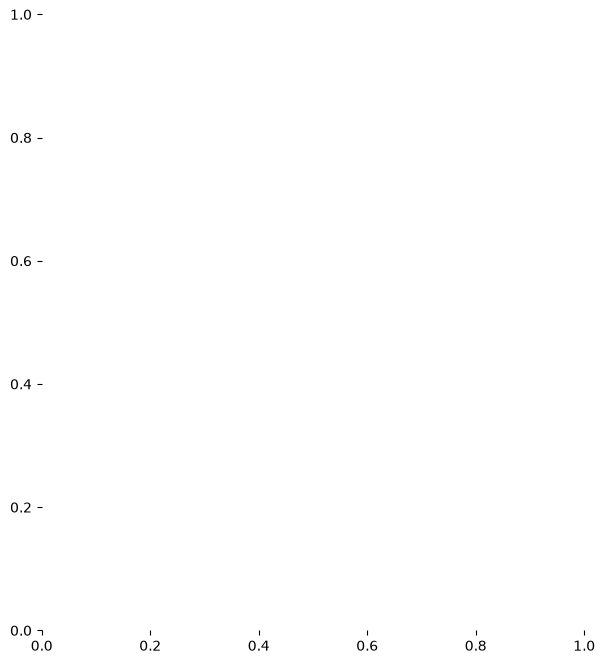

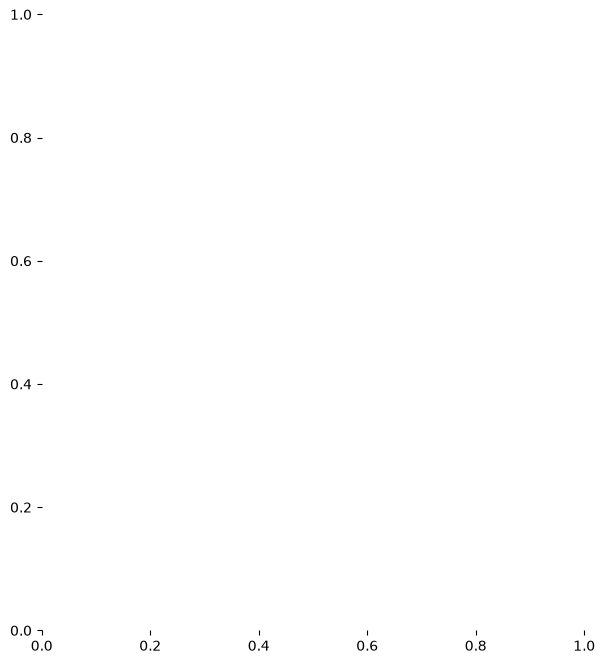

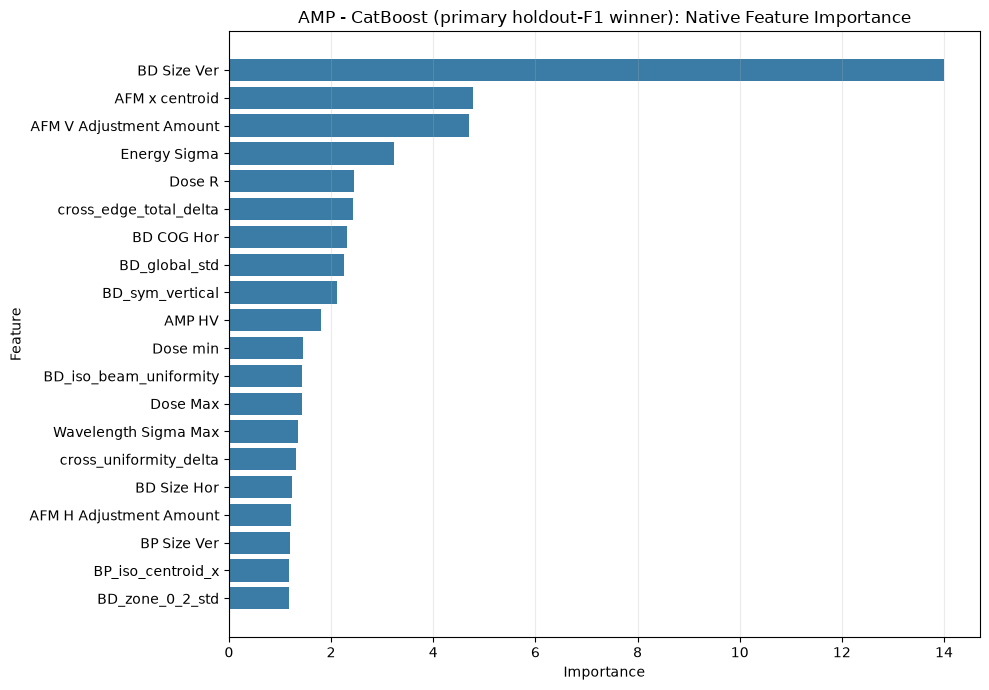

No native feature importance available for AMP - SVM.


In [113]:
plot_selected_native_importance("AMP", top_n=20)


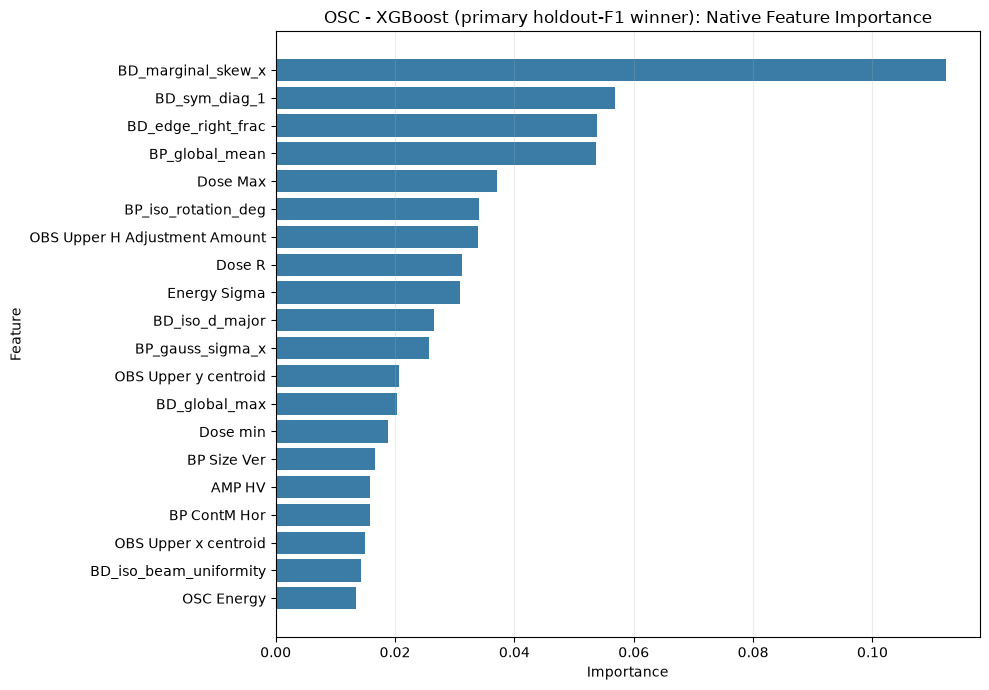

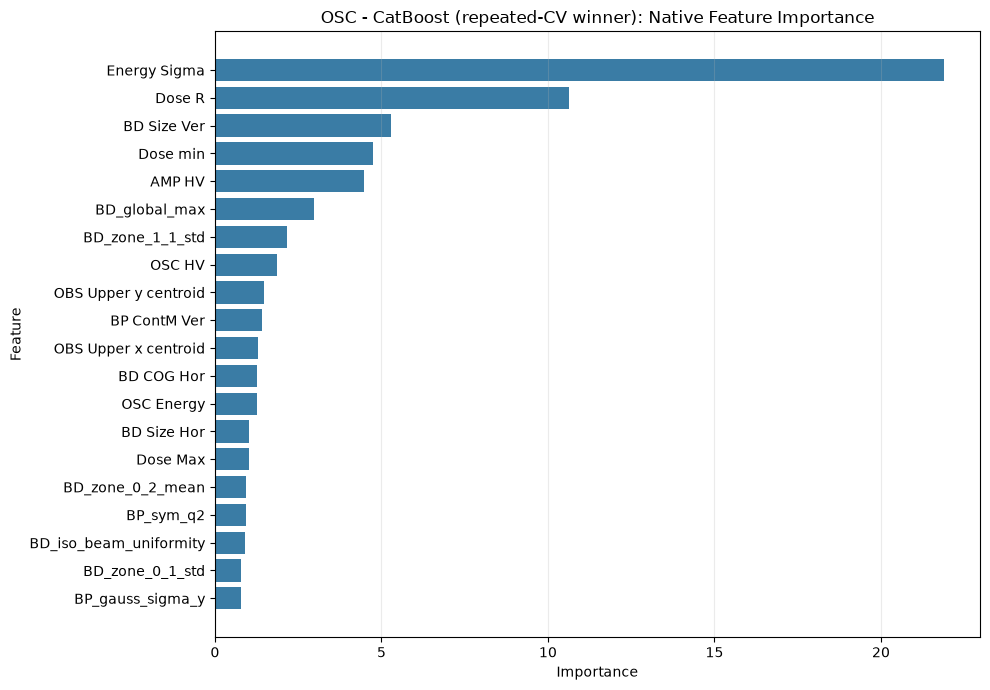

In [114]:
plot_selected_native_importance("OSC", top_n=20)


In [115]:
# Optional: inspect native importances for every fitted model that exposes them.
for dataset_name, models in model_registry.items():
    for model_name in models:
        if not native_importance_tables[dataset_name][model_name].empty:
            print(f"\n{dataset_name} - {model_name}")
            display(top_native_importance(dataset_name, model_name, top_n=10))



AMP - Random Forest


,feature,importance
0,BD Size Ver,0.071127
1,AFM x centroid,0.051994
2,AFM V Adjustment Amount,0.031245
3,AMP HV,0.030341
4,BD_sym_vertical,0.026227
5,Dose R,0.024955
6,Dose min,0.023645
7,Energy Sigma,0.021232
8,AFM H Adjustment Amount,0.019274
9,AFM y centroid,0.019272



AMP - LightGBM


,feature,importance
0,BD Size Ver,159
1,BD_global_std,67
2,Dose min,57
3,AFM x centroid,52
4,cross_edge_total_delta,47
5,AFM V Adjustment Amount,44
6,Energy Sigma,42
7,BD_gauss_amplitude,42
8,Dose Max,41
9,Dose R,39



AMP - XGBoost


...

,feature,importance
0,BD_marginal_skew_x,0.112399
1,BD_sym_diag_1,0.056848
2,BD_edge_right_frac,0.053851
3,BP_global_mean,0.053737
4,Dose Max,0.037088
5,BP_iso_rotation_deg,0.034115
6,OBS Upper H Adjustment Amount,0.033986
7,Dose R,0.031139
8,Energy Sigma,0.030883
9,BD_iso_d_major,0.026550



OSC - CatBoost


,feature,importance
0,Energy Sigma,21.879149
1,Dose R,10.627719
2,BD Size Ver,5.287887
3,Dose min,4.750207
4,AMP HV,4.490544
5,BD_global_max,2.978474
6,BD_zone_1_1_std,2.151570
7,OSC HV,1.852673
8,OBS Upper y centroid,1.474236
9,BP ContM Ver,1.403004



OSC - SVM


,feature,importance,coefficient
0,Energy Sigma,0.733532,-0.733532
1,Dose R,0.491121,-0.491121
2,Dose min,0.352150,0.352150
3,BD Size Ver,0.337563,-0.337563
4,BP_gauss_residual_max,0.326595,-0.326595
5,Dose Max,0.306958,-0.306958
6,AMP HV,0.297713,-0.297713
7,BD COG Hor,0.297621,-0.297621
8,BP_iso_ellipticity,0.270569,0.270569
9,OBS Upper y centroid,0.263219,-0.263219


## Step 5: Permutation Importance

Permutation importance measures how much holdout F1 drops when a feature is randomly shuffled. This is model-agnostic, so it works for tree models and SVM, including nonlinear SVM. Interpret correlated features carefully: importance can be split across redundant predictors.

In [116]:
from sklearn.inspection import permutation_importance


In [117]:
PERMUTATION_N_REPEATS = 30
PERMUTATION_SCORING = "f1"


def selected_model_items(dataset_name):
    selected = selected_model_registry[dataset_name]
    items = [("primary", selected["primary_name"], selected["primary"])]

    if selected["cv_winner_name"] != selected["primary_name"]:
        items.append(("cv_winner", selected["cv_winner_name"], selected["cv_winner"]))

    return items


def compute_permutation_importance_for_model(dataset_name, role, model_name, model, n_repeats=PERMUTATION_N_REPEATS):
    ctx = contexts[dataset_name]
    result = permutation_importance(
        model,
        ctx["X_test"],
        ctx["y_test"],
        scoring=PERMUTATION_SCORING,
        n_repeats=n_repeats,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    importance_df = pd.DataFrame(
        {
            "dataset": dataset_name,
            "role": role,
            "model": model_name,
            "feature": ctx["feature_names"],
            "importance_mean": result.importances_mean,
            "importance_std": result.importances_std,
        }
    )
    importance_df["importance_abs_mean"] = importance_df["importance_mean"].abs()
    importance_df["rank"] = importance_df["importance_mean"].rank(ascending=False, method="min").astype(int)

    return importance_df.sort_values("importance_mean", ascending=False).reset_index(drop=True)


In [118]:
permutation_importance_tables = {}
permutation_importance_all = []

for dataset_name in selected_model_registry:
    permutation_importance_tables[dataset_name] = {}

    for role, model_name, model in selected_model_items(dataset_name):
        print(f"Computing permutation importance: {dataset_name} - {model_name} ({role})")
        importance_df = compute_permutation_importance_for_model(dataset_name, role, model_name, model)
        permutation_importance_tables[dataset_name][role] = importance_df
        permutation_importance_all.append(importance_df)

permutation_importance_all = pd.concat(permutation_importance_all, ignore_index=True)
permutation_importance_all.head(20)


Computing permutation importance: AMP - CatBoost (primary)
Computing permutation importance: AMP - SVM (cv_winner)
Computing permutation importance: OSC - XGBoost (primary)
Computing permutation importance: OSC - CatBoost (cv_winner)


,dataset,role,model,feature,importance_mean,importance_std,importance_abs_mean,rank
0,AMP,primary,CatBoost,BD Size Ver,0.295645,0.073002,0.295645,1
1,AMP,primary,CatBoost,Energy Sigma,0.086735,0.046734,0.086735,2
2,AMP,primary,CatBoost,Dose min,0.049892,0.009265,0.049892,3
3,AMP,primary,CatBoost,BP ContM Ver,0.024086,0.025749,0.024086,4
4,AMP,primary,CatBoost,BP ContM Hor,0.020764,0.028930,0.020764,5
5,AMP,primary,CatBoost,cross_peak_ratio,0.016542,0.024390,0.016542,6
6,AMP,primary,CatBoost,cross_uniformity_delta,0.015603,0.027536,0.015603,7
7,AMP,primary,CatBoost,Dose Max,0.006882,0.017545,0.006882,8
8,AMP,primary,CatBoost,BP_iso_centroid_y,0.005161,0.015484,0.005161,9
9,AMP,primary,CatBoost,BP Size Ver,0.004697,0.025520,0.004697,10


In [119]:
def top_permutation_importance(dataset_name, role="primary", top_n=20, positive_only=False):
    importance_df = permutation_importance_tables[dataset_name][role].copy()
    if positive_only:
        importance_df = importance_df[importance_df["importance_mean"] > 0]

    cols = ["dataset", "role", "model", "feature", "importance_mean", "importance_std", "rank"]
    return importance_df.loc[:, cols].head(top_n)


top_permutation_importance("AMP", role="primary", top_n=20)


,dataset,role,model,feature,importance_mean,importance_std,rank
0,AMP,primary,CatBoost,BD Size Ver,0.295645,0.073002,1
1,AMP,primary,CatBoost,Energy Sigma,0.086735,0.046734,2
2,AMP,primary,CatBoost,Dose min,0.049892,0.009265,3
3,AMP,primary,CatBoost,BP ContM Ver,0.024086,0.025749,4
4,AMP,primary,CatBoost,BP ContM Hor,0.020764,0.028930,5
5,AMP,primary,CatBoost,cross_peak_ratio,0.016542,0.024390,6
6,AMP,primary,CatBoost,cross_uniformity_delta,0.015603,0.027536,7
7,AMP,primary,CatBoost,Dose Max,0.006882,0.017545,8
8,AMP,primary,CatBoost,BP_iso_centroid_y,0.005161,0.015484,9
9,AMP,primary,CatBoost,BP Size Ver,0.004697,0.025520,10


In [120]:
top_permutation_importance("OSC", role="primary", top_n=20)


,dataset,role,model,feature,importance_mean,importance_std,rank
0,OSC,primary,XGBoost,Energy Sigma,0.324996,0.102641,1
1,OSC,primary,XGBoost,BD Size Ver,0.260772,0.072845,2
2,OSC,primary,XGBoost,Dose R,0.232174,0.101757,3
3,OSC,primary,XGBoost,Dose Max,0.092232,0.044742,4
4,OSC,primary,XGBoost,BD_sym_horizontal,0.089577,0.054650,5
5,OSC,primary,XGBoost,AMP HV,0.084808,0.055690,6
6,OSC,primary,XGBoost,BD_zone_1_1_std,0.082713,0.058049,7
7,OSC,primary,XGBoost,Dose min,0.065215,0.053537,8
8,OSC,primary,XGBoost,BD_moment_energy_x_p50,0.057778,0.039924,9
9,OSC,primary,XGBoost,BD_marginal_skew_x,0.054222,0.040161,10


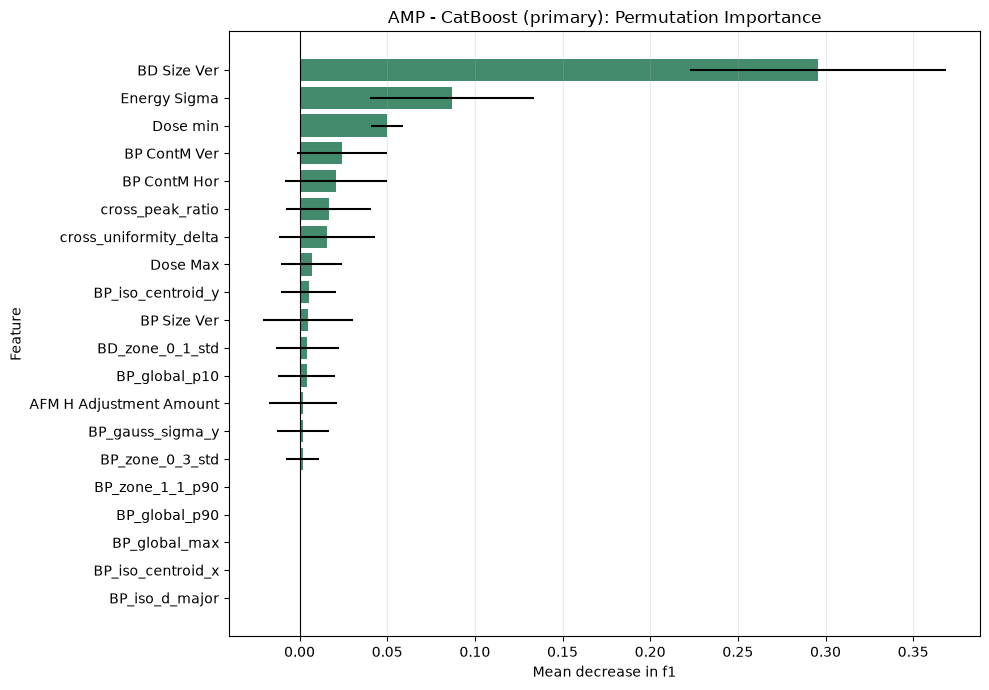

In [121]:
def plot_permutation_importance(dataset_name, role="primary", top_n=20, positive_only=False):
    importance_df = permutation_importance_tables[dataset_name][role].copy()
    if positive_only:
        importance_df = importance_df[importance_df["importance_mean"] > 0]

    if importance_df.empty:
        print(f"No positive permutation importances for {dataset_name} - {role}.")
        return

    plot_df = importance_df.head(top_n).iloc[::-1]
    model_name = plot_df["model"].iloc[0]

    colors = np.where(plot_df["importance_mean"] >= 0, "#2f7d5c", "#b65f5f")
    fig, ax = plt.subplots(figsize=(10, max(5, top_n * 0.35)))
    ax.barh(
        plot_df["feature"],
        plot_df["importance_mean"],
        xerr=plot_df["importance_std"],
        color=colors,
        alpha=0.9,
    )
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"{dataset_name} - {model_name} ({role}): Permutation Importance")
    ax.set_xlabel(f"Mean decrease in {PERMUTATION_SCORING}")
    ax.set_ylabel("Feature")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()


plot_permutation_importance("AMP", role="primary", top_n=20)


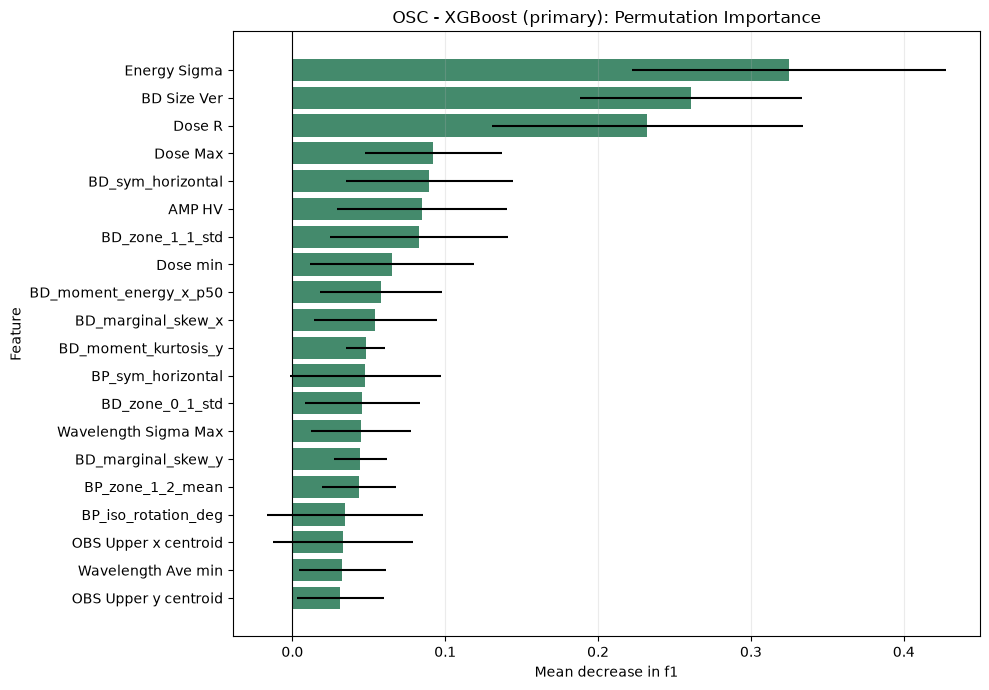

In [122]:
plot_permutation_importance("OSC", role="primary", top_n=20)



AMP repeated-CV winner permutation importance


,dataset,role,model,feature,importance_mean,importance_std,rank
0,AMP,cv_winner,SVM,BD Size Ver,0.072827,0.030867,1
1,AMP,cv_winner,SVM,AFM V Adjustment Amount,0.030695,0.039060,2
2,AMP,cv_winner,SVM,BD_gauss_sigma_y,0.028335,0.014020,3
3,AMP,cv_winner,SVM,AFM y centroid,0.023013,0.027615,4
4,AMP,cv_winner,SVM,AMP HV,0.015495,0.032043,5
5,AMP,cv_winner,SVM,OSC Energy,0.014918,0.019479,6
6,AMP,cv_winner,SVM,BD_global_p99,0.011874,0.013146,7
7,AMP,cv_winner,SVM,BP_iso_rotation_deg,0.011711,0.022995,8
8,AMP,cv_winner,SVM,BP ContM Ver,0.010462,0.016762,9
9,AMP,cv_winner,SVM,cross_sym_h_delta,0.010105,0.014596,10


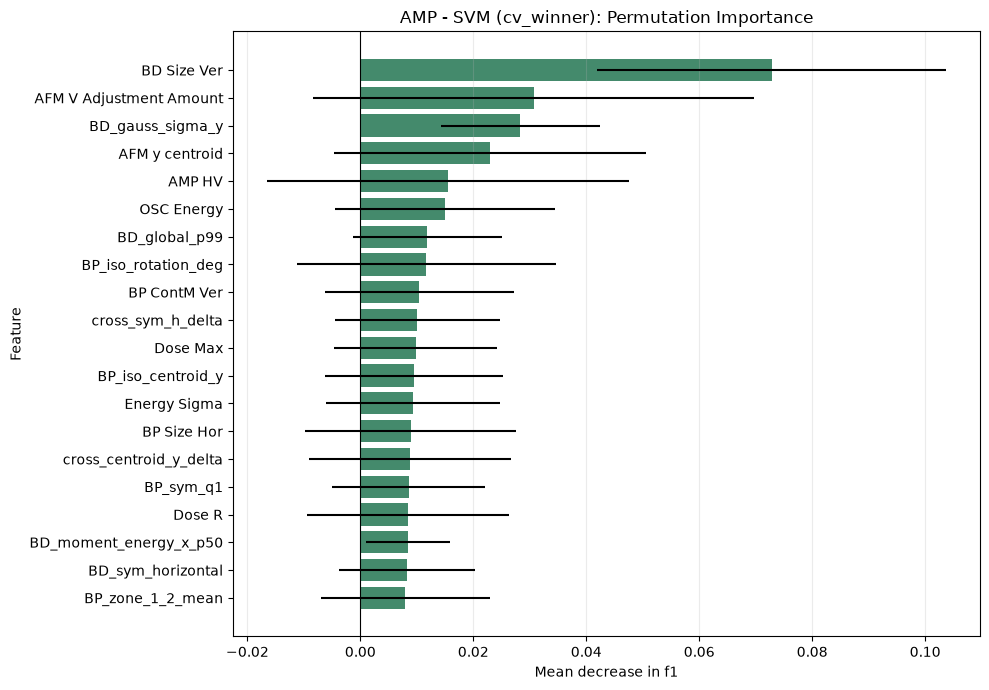


OSC repeated-CV winner permutation importance


,dataset,role,model,feature,importance_mean,importance_std,rank
0,OSC,cv_winner,CatBoost,Energy Sigma,0.123706,0.054140,1
1,OSC,cv_winner,CatBoost,Dose R,0.110681,0.081478,2
2,OSC,cv_winner,CatBoost,AMP HV,0.106546,0.060603,3
3,OSC,cv_winner,CatBoost,BD Size Ver,0.083042,0.045844,4
4,OSC,cv_winner,CatBoost,Dose min,0.044338,0.036158,5
5,OSC,cv_winner,CatBoost,BD_iso_edge_steepness,0.041734,0.013911,6
6,OSC,cv_winner,CatBoost,BP_gauss_sigma_y,0.040659,0.032100,7
7,OSC,cv_winner,CatBoost,BP_gauss_sigma_x,0.040188,0.015763,8
8,OSC,cv_winner,CatBoost,BP_sym_q2,0.038378,0.038491,9
9,OSC,cv_winner,CatBoost,BP_iso_edge_steepness,0.036834,0.025262,10


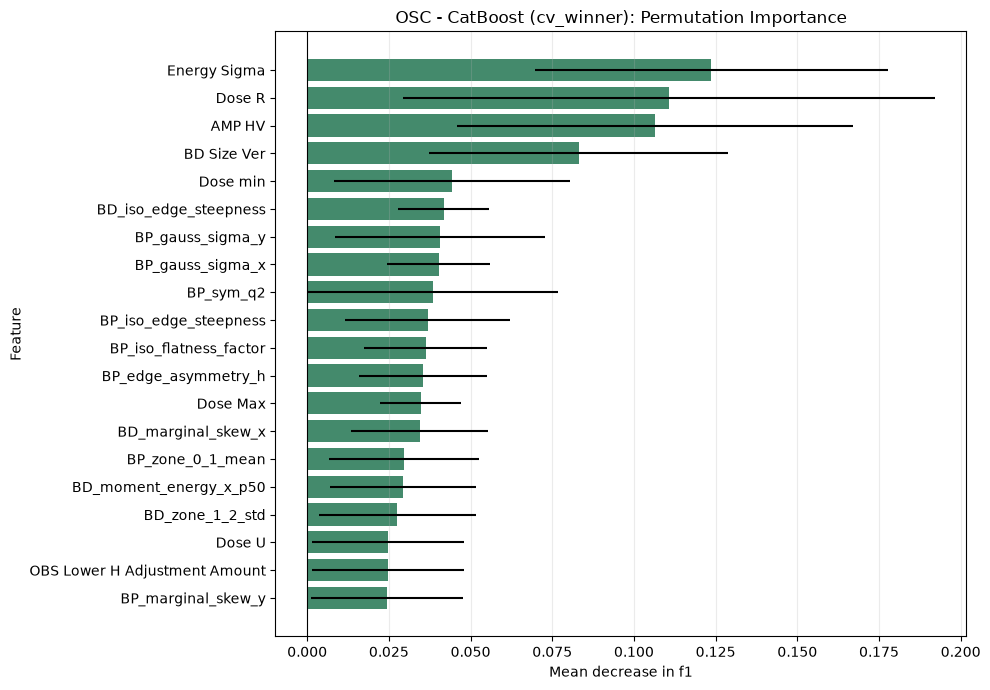

In [123]:
# CV-winner sensitivity views. These will run only for datasets where the CV winner differs from the primary model.
for dataset_name in selected_model_registry:
    available_roles = permutation_importance_tables[dataset_name].keys()
    if "cv_winner" in available_roles:
        print(f"\n{dataset_name} repeated-CV winner permutation importance")
        display(top_permutation_importance(dataset_name, role="cv_winner", top_n=20))
        plot_permutation_importance(dataset_name, role="cv_winner", top_n=20)


In [124]:
permutation_top_feature_summary = (
    permutation_importance_all
    .sort_values(["dataset", "role", "importance_mean"], ascending=[True, True, False])
    .groupby(["dataset", "role", "model"], as_index=False)
    .head(10)
)

permutation_top_feature_summary


,dataset,role,model,feature,importance_mean,importance_std,importance_abs_mean,rank
103,AMP,cv_winner,SVM,BD Size Ver,0.072827,0.030867,0.072827,1
104,AMP,cv_winner,SVM,AFM V Adjustment Amount,0.030695,0.039060,0.030695,2
105,AMP,cv_winner,SVM,BD_gauss_sigma_y,0.028335,0.014020,0.028335,3
106,AMP,cv_winner,SVM,AFM y centroid,0.023013,0.027615,0.023013,4
107,AMP,cv_winner,SVM,AMP HV,0.015495,0.032043,0.015495,5
108,AMP,cv_winner,SVM,OSC Energy,0.014918,0.019479,0.014918,6
109,AMP,cv_winner,SVM,BD_global_p99,0.011874,0.013146,0.011874,7
110,AMP,cv_winner,SVM,BP_iso_rotation_deg,0.011711,0.022995,0.011711,8
111,AMP,cv_winner,SVM,BP ContM Ver,0.010462,0.016762,0.010462,9
112,AMP,cv_winner,SVM,cross_sym_h_delta,0.010105,0.014596,0.010105,10


## Step 6: SHAP Analysis

SHAP explains prediction contributions feature by feature. Tree models use the fast tree explainer. SVM uses a model-agnostic explainer on sampled data, which is slower, so the background and explanation sample sizes are intentionally capped.

In [125]:
try:
    import shap
except ImportError as exc:
    raise ImportError(
        "SHAP is not installed in this notebook kernel. Install it with `pip install shap` or add it to the project environment."
    ) from exc

SHAP_BACKGROUND_SIZE = 50
SHAP_EXPLAIN_SIZE = 80
SHAP_RANDOM_STATE = RANDOM_STATE
TREE_MODEL_NAMES = {"Random Forest", "LightGBM", "XGBoost", "CatBoost"}


In [126]:
def sample_for_shap(X, n, random_state=SHAP_RANDOM_STATE):
    if len(X) <= n:
        return X.copy()
    return X.sample(n=n, random_state=random_state)


def predict_positive_probability(model, X):
    proba = model.predict_proba(X)
    if proba.ndim == 2:
        return proba[:, 1]
    return proba


def normalize_shap_values(raw_values):
    if isinstance(raw_values, list):
        return raw_values[1] if len(raw_values) > 1 else raw_values[0]

    values = np.asarray(raw_values)
    if values.ndim == 3:
        return values[:, :, 1] if values.shape[2] > 1 else values[:, :, 0]

    return values


In [127]:
def compute_shap_for_model(dataset_name, role="primary"):
    selected = selected_model_registry[dataset_name]
    model = selected[role]
    model_name = selected[f"{role}_name"] if role == "primary" else selected["cv_winner_name"]
    ctx = contexts[dataset_name]

    X_train_bg = sample_for_shap(ctx["X_train"], SHAP_BACKGROUND_SIZE)
    X_explain = sample_for_shap(ctx["X_test"], SHAP_EXPLAIN_SIZE)

    if model_name in TREE_MODEL_NAMES:
        explainer = shap.TreeExplainer(model)
        raw_values = explainer.shap_values(X_explain)
        shap_values = normalize_shap_values(raw_values)
        expected_value = explainer.expected_value
        if isinstance(expected_value, (list, np.ndarray)) and np.asarray(expected_value).ndim > 0:
            expected_value = np.asarray(expected_value).ravel()[-1]
        explainer_type = "TreeExplainer"
    else:
        # KernelExplainer works for nonlinear SVM but is expensive; sampled background/test rows keep it tractable.
        explainer = shap.KernelExplainer(lambda data: predict_positive_probability(model, pd.DataFrame(data, columns=ctx["feature_names"])), X_train_bg)
        shap_values = explainer.shap_values(X_explain, nsamples="auto")
        shap_values = normalize_shap_values(shap_values)
        expected_value = explainer.expected_value
        if isinstance(expected_value, (list, np.ndarray)) and np.asarray(expected_value).ndim > 0:
            expected_value = np.asarray(expected_value).ravel()[-1]
        explainer_type = "KernelExplainer"

    return {
        "dataset": dataset_name,
        "role": role,
        "model_name": model_name,
        "model": model,
        "explainer": explainer,
        "explainer_type": explainer_type,
        "expected_value": expected_value,
        "X_explain": X_explain,
        "shap_values": shap_values,
    }


In [128]:
shap_results = {}

for dataset_name in selected_model_registry:
    shap_results[dataset_name] = {}
    roles = ["primary"]
    if selected_model_registry[dataset_name]["cv_winner_name"] != selected_model_registry[dataset_name]["primary_name"]:
        roles.append("cv_winner")

    for role in roles:
        model_label = selected_model_registry[dataset_name]["primary_name"] if role == "primary" else selected_model_registry[dataset_name]["cv_winner_name"]
        print(f"Computing SHAP: {dataset_name} - {model_label} ({role})")
        shap_results[dataset_name][role] = compute_shap_for_model(dataset_name, role=role)

[(dataset, role, result["model_name"], result["explainer_type"], result["X_explain"].shape) for dataset, roles in shap_results.items() for role, result in roles.items()]


Computing SHAP: AMP - CatBoost (primary)
Computing SHAP: AMP - SVM (cv_winner)


100%|██████████| 80/80 [03:49<00:00,  2.87s/it]


Computing SHAP: OSC - XGBoost (primary)
Computing SHAP: OSC - CatBoost (cv_winner)


[('AMP', 'primary', 'CatBoost', 'TreeExplainer', (80, 103)),
 ('AMP', 'cv_winner', 'SVM', 'KernelExplainer', (80, 103)),
 ('OSC', 'primary', 'XGBoost', 'TreeExplainer', (80, 110)),
 ('OSC', 'cv_winner', 'CatBoost', 'TreeExplainer', (80, 110))]

In [129]:
def shap_importance_table(dataset_name, role="primary", top_n=20):
    result = shap_results[dataset_name][role]
    values = np.asarray(result["shap_values"])
    mean_abs = np.abs(values).mean(axis=0)

    return (
        pd.DataFrame({"feature": result["X_explain"].columns, "mean_abs_shap": mean_abs})
        .sort_values("mean_abs_shap", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )


shap_importance_table("AMP", role="primary", top_n=20)


,feature,mean_abs_shap
0,BD Size Ver,0.988540
1,AFM x centroid,0.422650
2,AFM V Adjustment Amount,0.311132
3,Energy Sigma,0.280664
4,BD COG Hor,0.215545
5,cross_edge_total_delta,0.173373
6,BD_global_std,0.150267
7,Dose R,0.140762
8,Dose Max,0.107307
9,AMP HV,0.104461


In [130]:
shap_importance_table("OSC", role="primary", top_n=20)


,feature,mean_abs_shap
0,Energy Sigma,1.532435
1,Dose R,0.868361
2,BD Size Ver,0.602413
3,AMP HV,0.570261
4,BD COG Hor,0.396256
5,OSC HV,0.341534
6,BD_zone_1_1_std,0.215008
7,Dose min,0.195136
8,Dose Max,0.189668
9,BD_sym_horizontal,0.160099


AMP - CatBoost (primary) SHAP bar


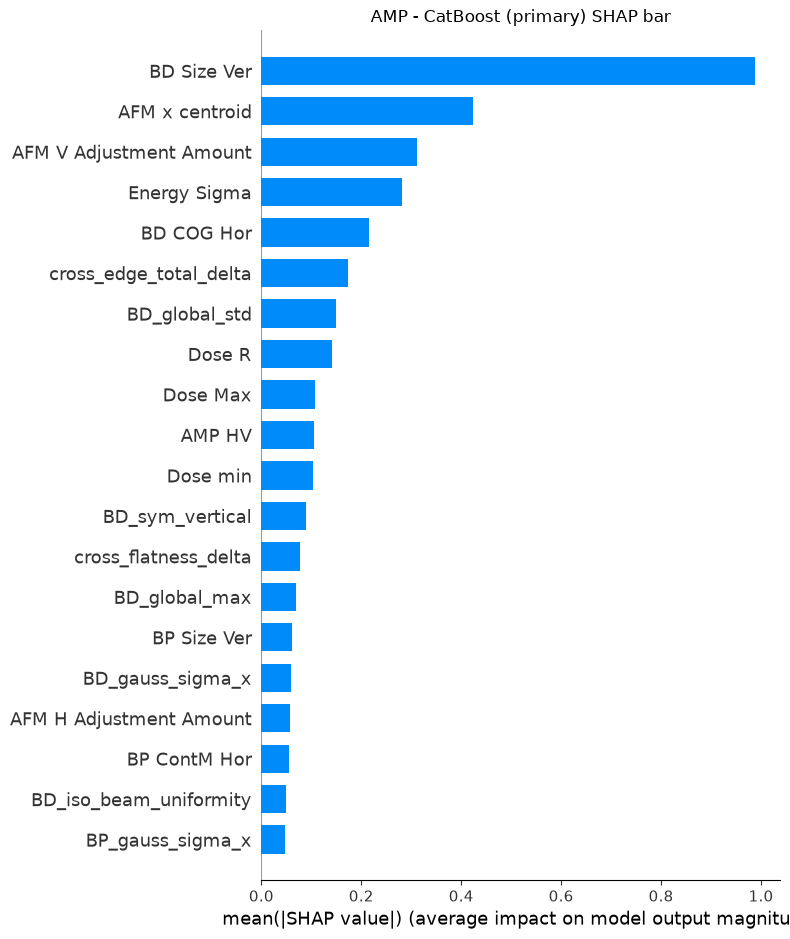

In [131]:
def plot_shap_summary(dataset_name, role="primary", plot_type="bar", max_display=20):
    result = shap_results[dataset_name][role]
    title = f"{dataset_name} - {result['model_name']} ({role}) SHAP {plot_type}"
    print(title)
    shap.summary_plot(
        result["shap_values"],
        result["X_explain"],
        plot_type=plot_type,
        max_display=max_display,
        show=False,
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()


plot_shap_summary("AMP", role="primary", plot_type="bar", max_display=20)


OSC - XGBoost (primary) SHAP bar


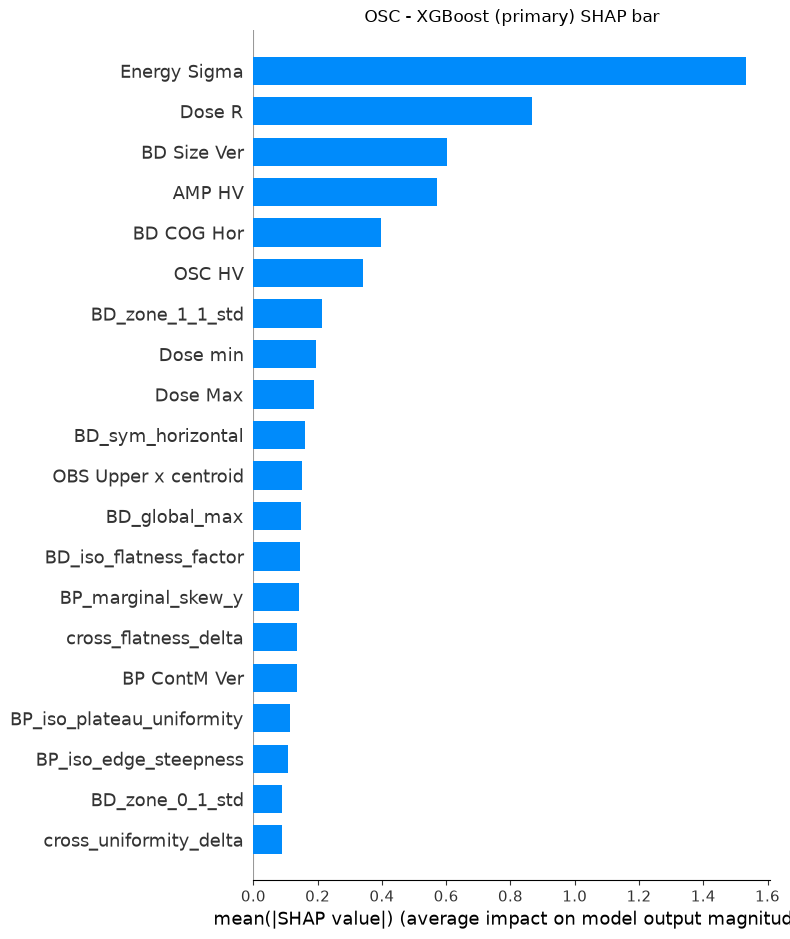

In [132]:
plot_shap_summary("OSC", role="primary", plot_type="bar", max_display=20)


AMP - CatBoost (primary) SHAP dot


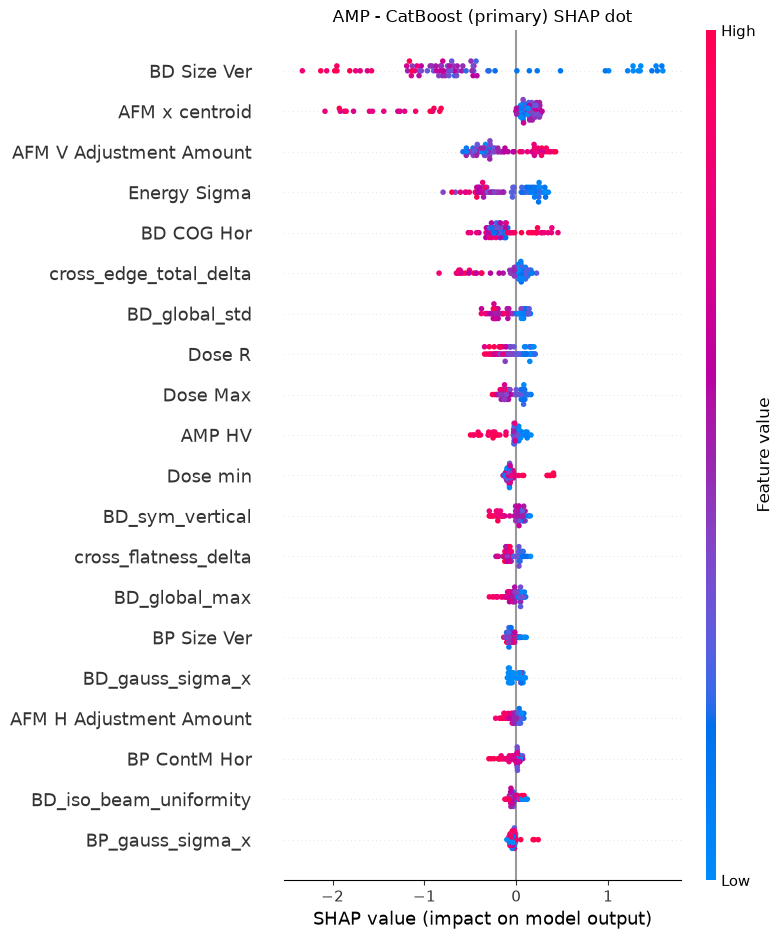

In [133]:
plot_shap_summary("AMP", role="primary", plot_type="dot", max_display=20)


OSC - XGBoost (primary) SHAP dot


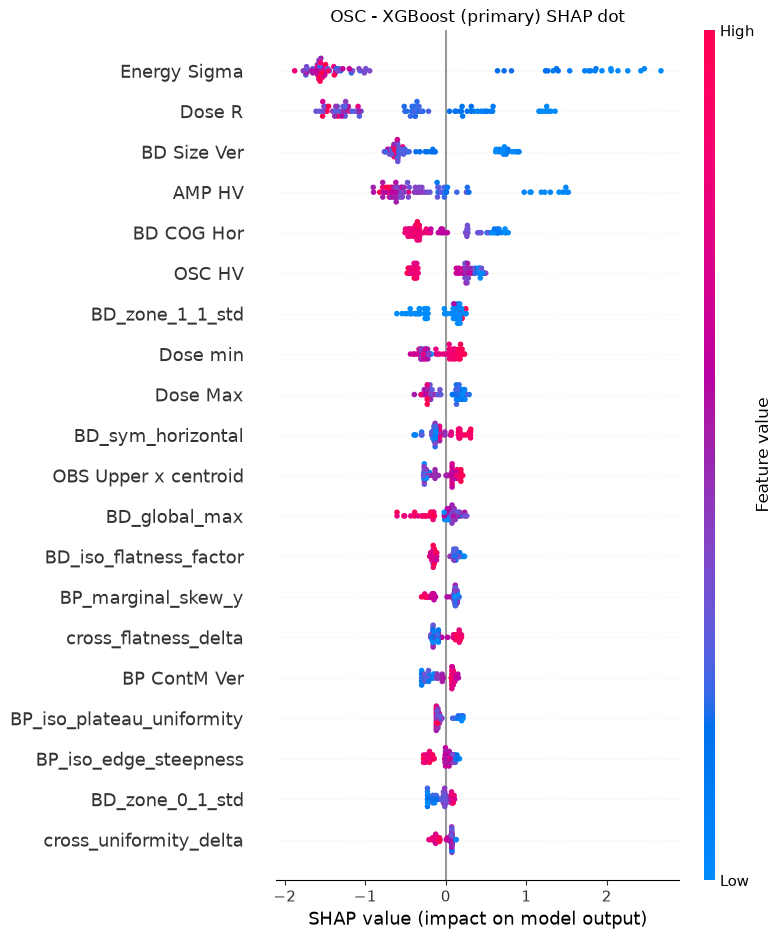

In [134]:
plot_shap_summary("OSC", role="primary", plot_type="dot", max_display=20)



AMP repeated-CV winner SHAP importance


,feature,mean_abs_shap
0,AFM V Adjustment Amount,0.032007
1,AFM y centroid,0.028711
2,BD Size Ver,0.025857
3,AMP HV,0.016293
4,AFM H Adjustment Amount,0.011998
5,Dose R,0.010179
6,Energy Sigma,0.009977
7,BP_iso_rotation_deg,0.007256
8,BP ContM Ver,0.006884
9,BP Size Hor,0.006486


AMP - SVM (cv_winner) SHAP bar


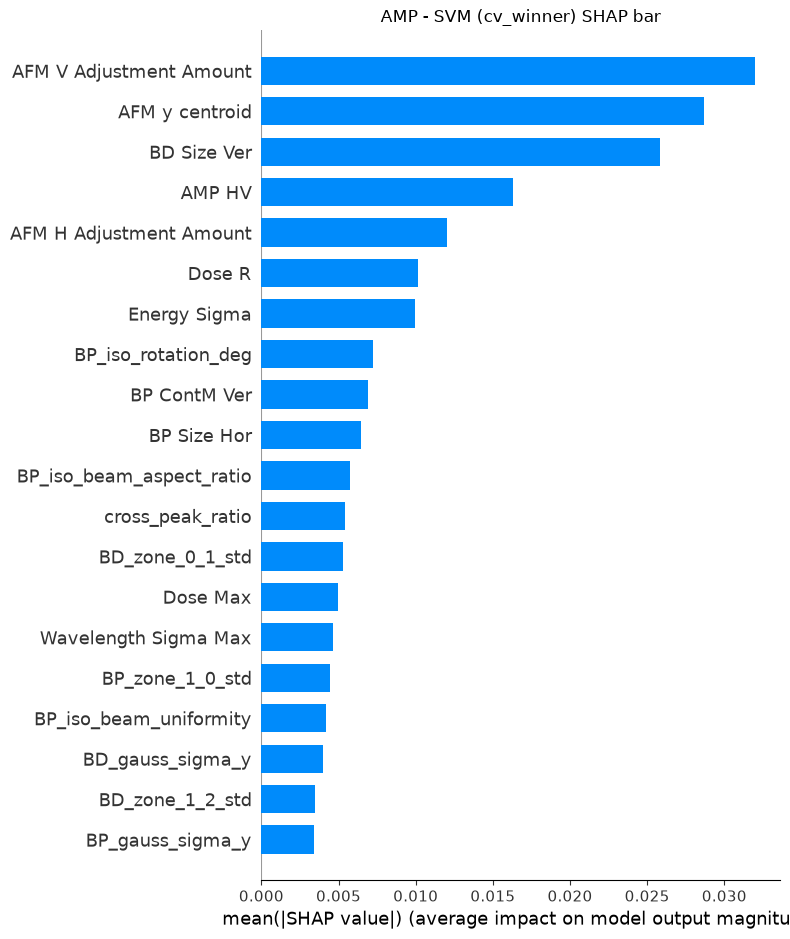


OSC repeated-CV winner SHAP importance


,feature,mean_abs_shap
0,Energy Sigma,1.906099
1,Dose R,0.978479
2,AMP HV,0.443537
3,BD Size Ver,0.427792
4,Dose min,0.355139
5,BD_global_max,0.242937
6,BD_zone_1_1_std,0.228185
7,Dose Max,0.138039
8,OBS Upper y centroid,0.132158
9,BP_zone_1_2_mean,0.110311


OSC - CatBoost (cv_winner) SHAP bar


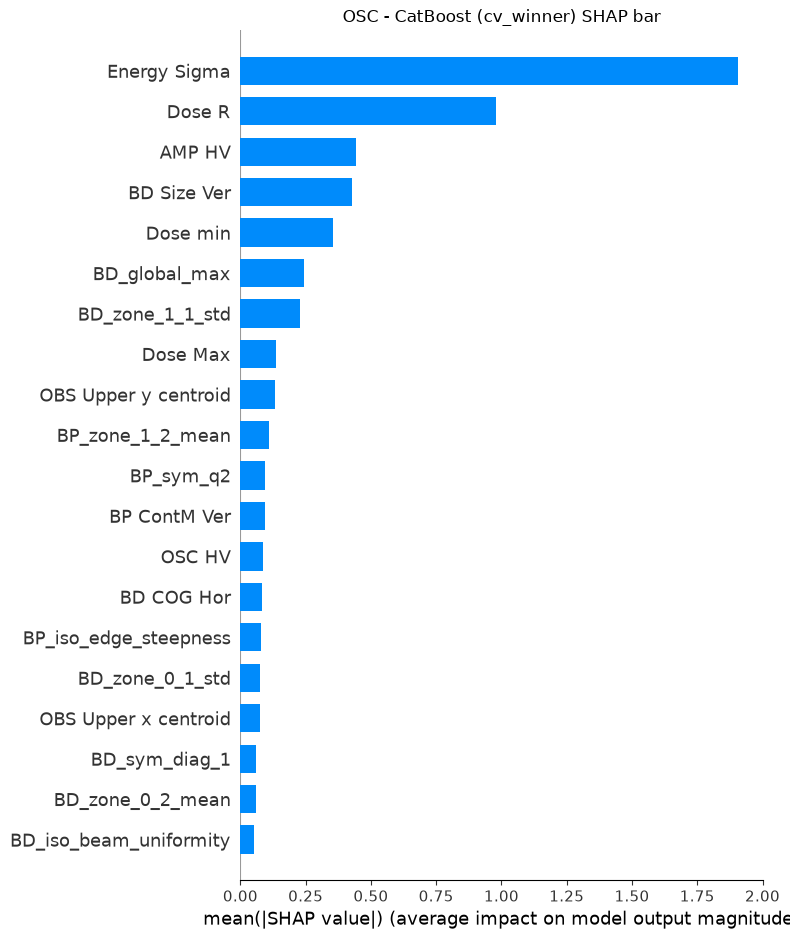

In [135]:
# CV-winner SHAP sensitivity views, only where different from the primary model.
for dataset_name, roles in shap_results.items():
    if "cv_winner" in roles:
        print(f"\n{dataset_name} repeated-CV winner SHAP importance")
        display(shap_importance_table(dataset_name, role="cv_winner", top_n=20))
        plot_shap_summary(dataset_name, role="cv_winner", plot_type="bar", max_display=20)


AMP - CatBoost (primary): BD Size Ver


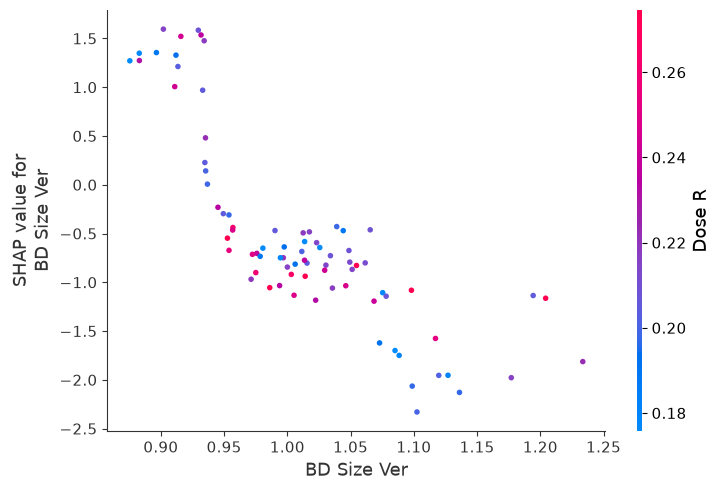

AMP - CatBoost (primary): AFM x centroid


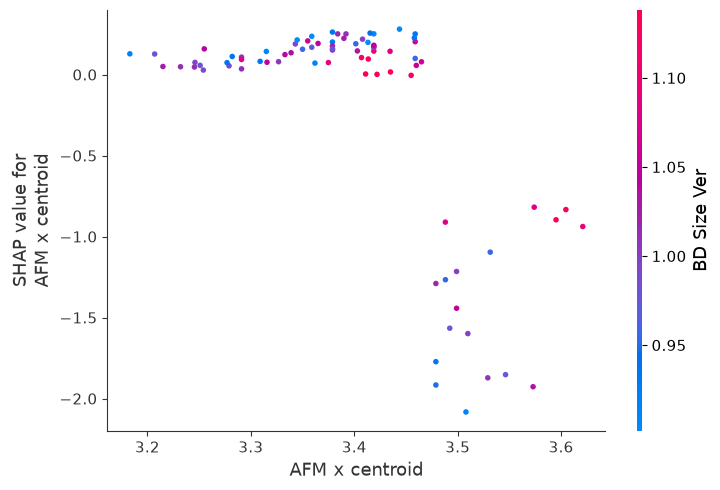

AMP - CatBoost (primary): AFM V Adjustment Amount


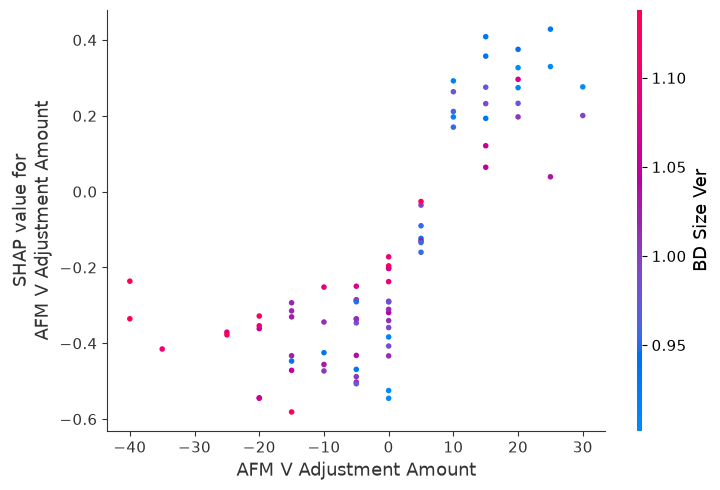

In [136]:
def plot_shap_dependence_for_top_features(dataset_name, role="primary", top_n=3):
    top_features = shap_importance_table(dataset_name, role=role, top_n=top_n)["feature"].tolist()
    result = shap_results[dataset_name][role]

    for feature in top_features:
        print(f"{dataset_name} - {result['model_name']} ({role}): {feature}")
        shap.dependence_plot(
            feature,
            result["shap_values"],
            result["X_explain"],
            show=False,
        )
        plt.tight_layout()
        plt.show()


plot_shap_dependence_for_top_features("AMP", role="primary", top_n=3)


OSC - XGBoost (primary): Energy Sigma


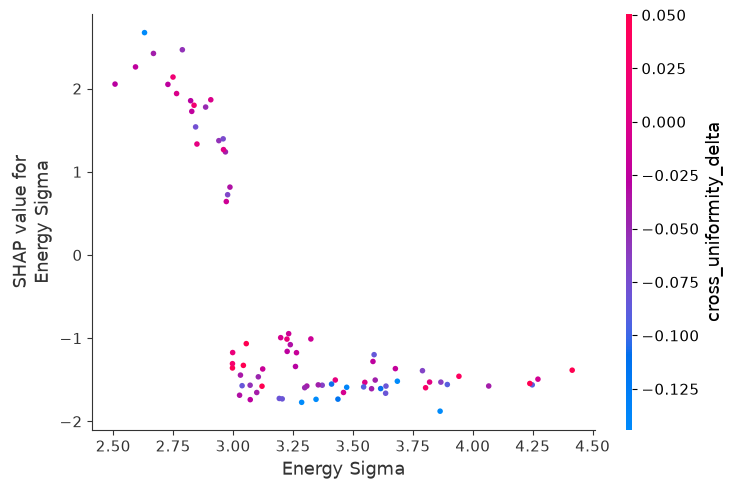

OSC - XGBoost (primary): Dose R


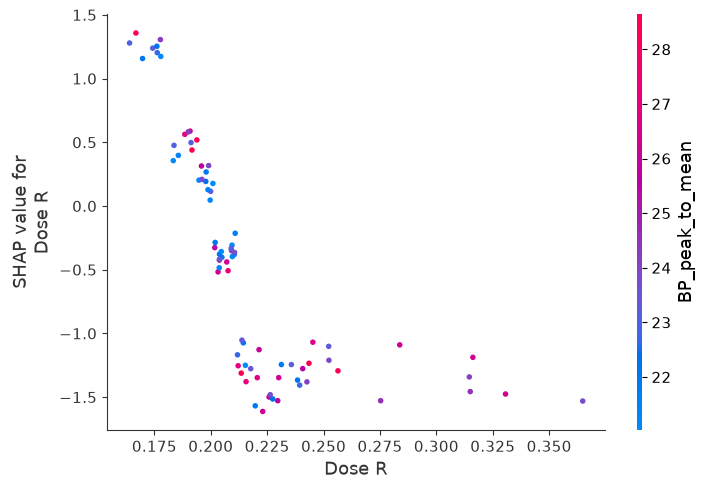

OSC - XGBoost (primary): BD Size Ver


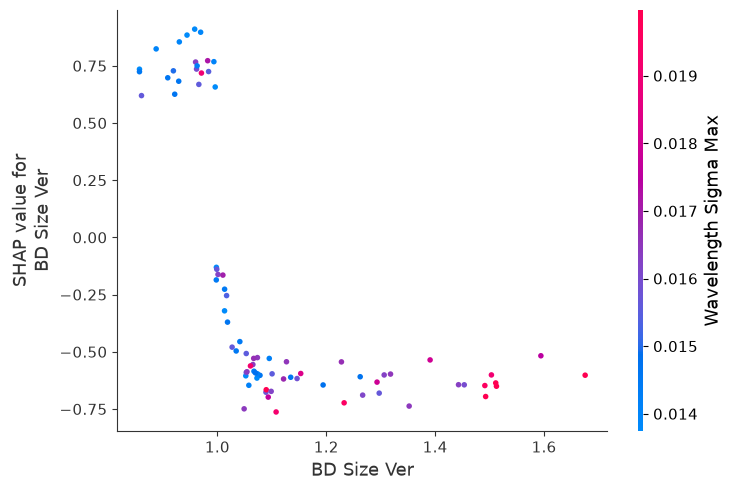

In [137]:
plot_shap_dependence_for_top_features("OSC", role="primary", top_n=3)


## Step 7: Local SHAP Case Studies

Global plots show broad behavior. Local explanations show why a specific holdout sample was predicted as OK or NG. This section selects representative true positives, true negatives, false positives, and false negatives, then explains individual predictions with SHAP waterfall plots.

In [138]:
def prediction_case_table(dataset_name, role="primary"):
    selected = selected_model_registry[dataset_name]
    model = selected[role]
    model_name = selected[f"{role}_name"] if role == "primary" else selected["cv_winner_name"]
    ctx = contexts[dataset_name]

    pred = model.predict(ctx["X_test"])
    proba_ok = predict_positive_probability(model, ctx["X_test"]) if hasattr(model, "predict_proba") else np.full(len(pred), np.nan)

    cases = pd.DataFrame(
        {
            "dataset": dataset_name,
            "role": role,
            "model": model_name,
            "sample_id": ctx["X_test"].index,
            "y_true": ctx["y_test"].to_numpy(),
            "y_pred": pred,
            "proba_ok": proba_ok,
        },
        index=ctx["X_test"].index,
    )
    cases["case_type"] = np.select(
        [
            (cases["y_true"] == 1) & (cases["y_pred"] == 1),
            (cases["y_true"] == 0) & (cases["y_pred"] == 0),
            (cases["y_true"] == 0) & (cases["y_pred"] == 1),
            (cases["y_true"] == 1) & (cases["y_pred"] == 0),
        ],
        ["true_positive", "true_negative", "false_positive", "false_negative"],
        default="unknown",
    )

    return cases


prediction_cases = {
    dataset_name: {
        role: prediction_case_table(dataset_name, role=role)
        for role in shap_results[dataset_name]
    }
    for dataset_name in shap_results
}

prediction_cases["AMP"]["primary"].groupby("case_type").size()


case_type
false_negative     7
false_positive    10
true_negative     58
true_positive      7
dtype: int64

In [139]:
def select_representative_cases(dataset_name, role="primary"):
    cases = prediction_cases[dataset_name][role].copy()
    selected_rows = []

    selection_rules = {
        "true_positive": lambda df: df.sort_values("proba_ok", ascending=False),
        "true_negative": lambda df: df.sort_values("proba_ok", ascending=True),
        "false_positive": lambda df: df.sort_values("proba_ok", ascending=False),
        "false_negative": lambda df: df.sort_values("proba_ok", ascending=True),
    }

    for case_type, sorter in selection_rules.items():
        subset = cases[cases["case_type"] == case_type]
        if subset.empty:
            continue
        selected_rows.append(sorter(subset).head(1))

    if not selected_rows:
        return pd.DataFrame(columns=cases.columns)

    return pd.concat(selected_rows).reset_index(drop=True)


representative_cases = {
    dataset_name: {
        role: select_representative_cases(dataset_name, role=role)
        for role in shap_results[dataset_name]
    }
    for dataset_name in shap_results
}

representative_cases["AMP"]["primary"]


,dataset,role,model,sample_id,y_true,y_pred,proba_ok,case_type
0,AMP,primary,CatBoost,175,1,1,0.929680,true_positive
1,AMP,primary,CatBoost,154,0,0,0.010056,true_negative
2,AMP,primary,CatBoost,52,0,1,0.913466,false_positive
3,AMP,primary,CatBoost,244,1,0,0.030237,false_negative


In [140]:
representative_cases["OSC"]["primary"]


,dataset,role,model,sample_id,y_true,y_pred,proba_ok,case_type
0,OSC,primary,XGBoost,182,1,1,0.993899,true_positive
1,OSC,primary,XGBoost,7,0,0,0.000332,true_negative
2,OSC,primary,XGBoost,301,0,1,0.969974,false_positive
3,OSC,primary,XGBoost,107,1,0,0.032487,false_negative


In [141]:
def get_shap_row_for_sample(dataset_name, role, sample_id):
    result = shap_results[dataset_name][role]
    X_explain = result["X_explain"]

    if sample_id not in X_explain.index:
        return None

    row_position = X_explain.index.get_loc(sample_id)
    if isinstance(row_position, slice):
        row_position = row_position.start

    return row_position


def ensure_case_samples_have_shap(dataset_name, role="primary"):
    result = shap_results[dataset_name][role]
    case_ids = representative_cases[dataset_name][role]["sample_id"].tolist()
    missing_ids = [sample_id for sample_id in case_ids if sample_id not in result["X_explain"].index]

    if not missing_ids:
        return

    print(
        f"Warning: {dataset_name} - {role} has representative cases outside the sampled SHAP rows: {missing_ids}. "
        "Increase SHAP_EXPLAIN_SIZE or rerun SHAP with all representative cases included."
    )


for dataset_name, roles in representative_cases.items():
    for role in roles:
        ensure_case_samples_have_shap(dataset_name, role=role)


In [142]:
def shap_local_contribution_table(dataset_name, role, sample_id, top_n=12):
    row_position = get_shap_row_for_sample(dataset_name, role, sample_id)
    if row_position is None:
        print(f"Sample {sample_id} is not in shap_results[{dataset_name!r}][{role!r}]['X_explain'].")
        return pd.DataFrame()

    result = shap_results[dataset_name][role]
    x_row = result["X_explain"].iloc[row_position]
    shap_row = np.asarray(result["shap_values"])[row_position]

    contrib = pd.DataFrame(
        {
            "feature": result["X_explain"].columns,
            "feature_value": x_row.to_numpy(),
            "shap_value": shap_row,
            "abs_shap_value": np.abs(shap_row),
            "direction": np.where(shap_row >= 0, "pushes_OK", "pushes_NG"),
        }
    )

    return contrib.sort_values("abs_shap_value", ascending=False).head(top_n).reset_index(drop=True)


first_amp_case_id = representative_cases["AMP"]["primary"]["sample_id"].iloc[0]
shap_local_contribution_table("AMP", "primary", first_amp_case_id, top_n=12)


,feature,feature_value,shap_value,abs_shap_value,direction
0,BD Size Ver,0.896478,1.355151,1.355151,pushes_OK
1,AFM x centroid,3.443741,0.280589,0.280589,pushes_OK
2,AFM V Adjustment Amount,30.000000,0.276306,0.276306,pushes_OK
3,Energy Sigma,2.934758,0.191814,0.191814,pushes_OK
4,cross_peak_ratio,0.989911,-0.147317,0.147317,pushes_NG
5,cross_edge_total_delta,-0.116287,0.144503,0.144503,pushes_OK
6,BD COG Hor,6.796652,-0.133944,0.133944,pushes_NG
7,BP_iso_beam_uniformity,0.535192,-0.121373,0.121373,pushes_NG
8,AMP HV,19.208499,0.120608,0.120608,pushes_OK
9,BD_global_std,53.366314,-0.098181,0.098181,pushes_NG


AMP - CatBoost (primary) | sample_id=175 | true_positive | true=1 | pred=1 | P(OK)=0.930


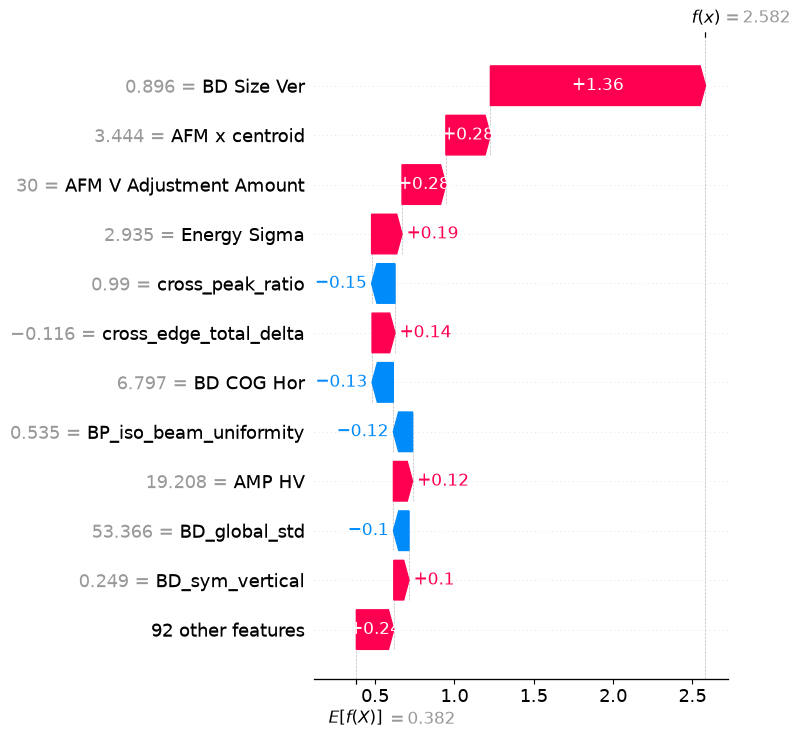

AMP - CatBoost (primary) | sample_id=154 | true_negative | true=0 | pred=0 | P(OK)=0.010


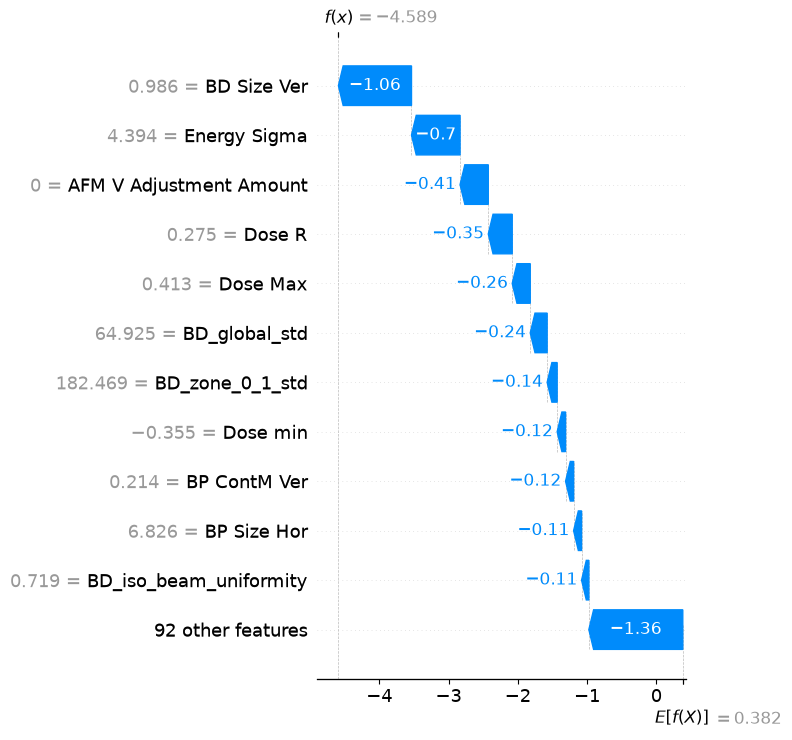

Sample 52 is not available in the sampled SHAP explanation set.
AMP - CatBoost (primary) | sample_id=244 | false_negative | true=1 | pred=0 | P(OK)=0.030


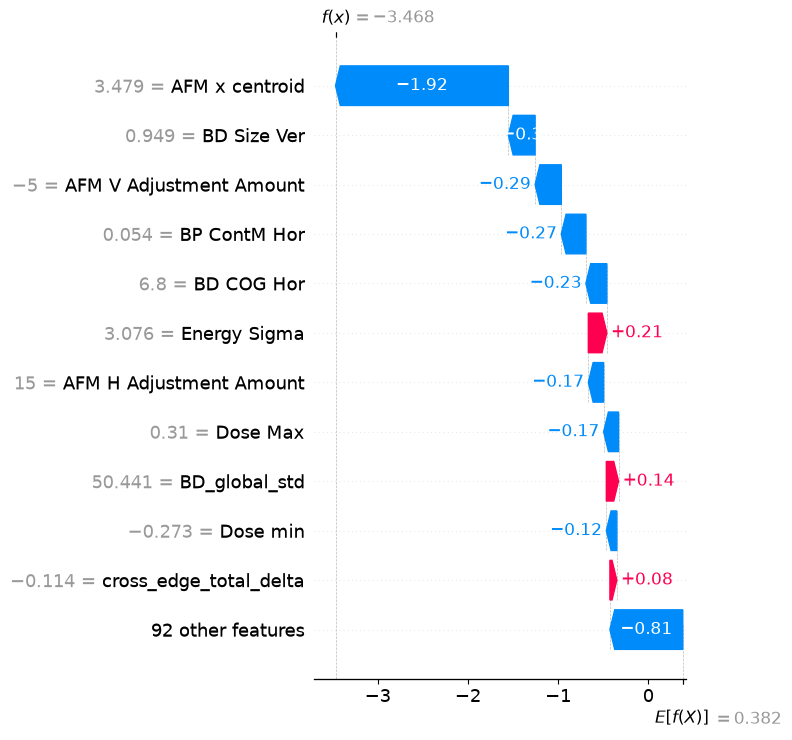

In [143]:
def plot_shap_waterfall_for_sample(dataset_name, role, sample_id, max_display=12):
    row_position = get_shap_row_for_sample(dataset_name, role, sample_id)
    if row_position is None:
        print(f"Sample {sample_id} is not available in the sampled SHAP explanation set.")
        return

    result = shap_results[dataset_name][role]
    cases = prediction_cases[dataset_name][role]
    case_row = cases.loc[sample_id]
    x_row = result["X_explain"].iloc[row_position]
    shap_row = np.asarray(result["shap_values"])[row_position]

    explanation = shap.Explanation(
        values=shap_row,
        base_values=result["expected_value"],
        data=x_row.to_numpy(),
        feature_names=result["X_explain"].columns.tolist(),
    )

    print(
        f"{dataset_name} - {result['model_name']} ({role}) | sample_id={sample_id} | "
        f"{case_row['case_type']} | true={case_row['y_true']} | pred={case_row['y_pred']} | "
        f"P(OK)={case_row['proba_ok']:.3f}"
    )
    shap.plots.waterfall(explanation, max_display=max_display, show=False)
    plt.tight_layout()
    plt.show()


for _, case in representative_cases["AMP"]["primary"].iterrows():
    plot_shap_waterfall_for_sample("AMP", "primary", case["sample_id"], max_display=12)


OSC - XGBoost (primary) | sample_id=182 | true_positive | true=1 | pred=1 | P(OK)=0.994


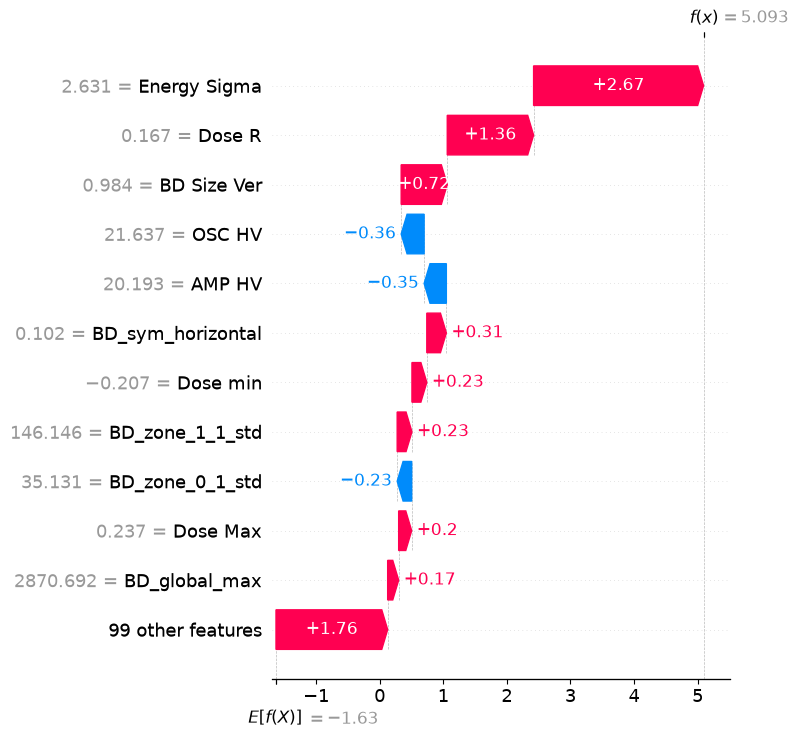

OSC - XGBoost (primary) | sample_id=7 | true_negative | true=0 | pred=0 | P(OK)=0.000


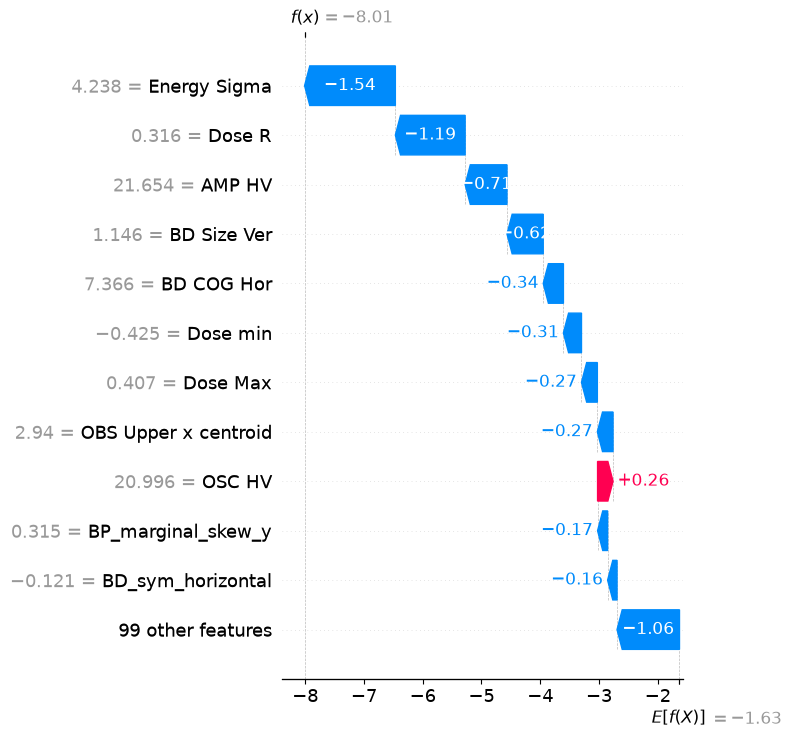

OSC - XGBoost (primary) | sample_id=301 | false_positive | true=0 | pred=1 | P(OK)=0.970


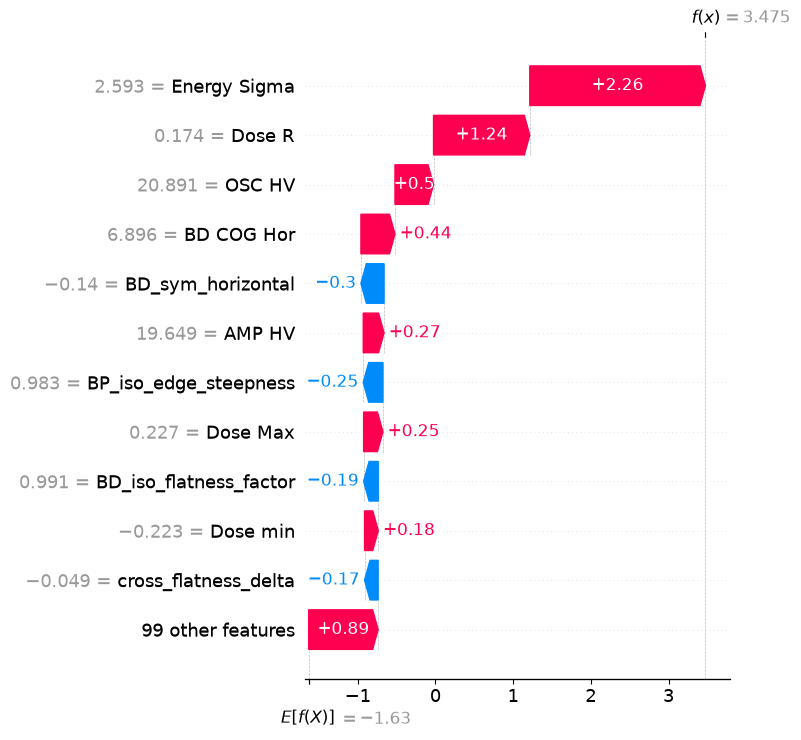

OSC - XGBoost (primary) | sample_id=107 | false_negative | true=1 | pred=0 | P(OK)=0.032


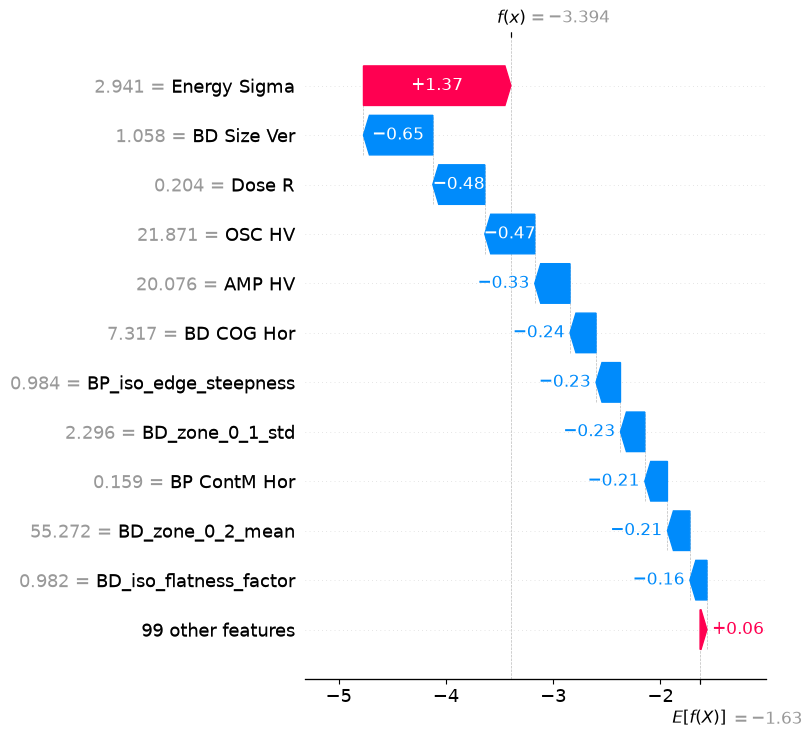

In [144]:
for _, case in representative_cases["OSC"]["primary"].iterrows():
    plot_shap_waterfall_for_sample("OSC", "primary", case["sample_id"], max_display=12)



AMP CV-winner local cases


,dataset,role,model,sample_id,y_true,y_pred,proba_ok,case_type
0,AMP,cv_winner,SVM,175,1,1,0.571921,true_positive
1,AMP,cv_winner,SVM,139,0,0,0.002325,true_negative
2,AMP,cv_winner,SVM,223,0,1,0.602285,false_positive
3,AMP,cv_winner,SVM,169,1,0,0.069719,false_negative


AMP - SVM (cv_winner) | sample_id=175 | true_positive | true=1 | pred=1 | P(OK)=0.572


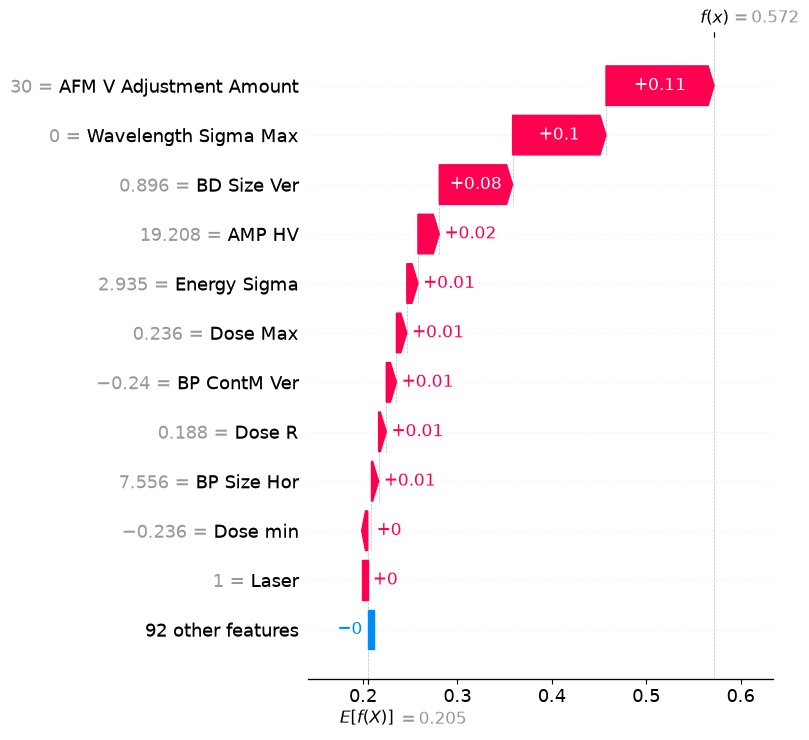

AMP - SVM (cv_winner) | sample_id=139 | true_negative | true=0 | pred=0 | P(OK)=0.002


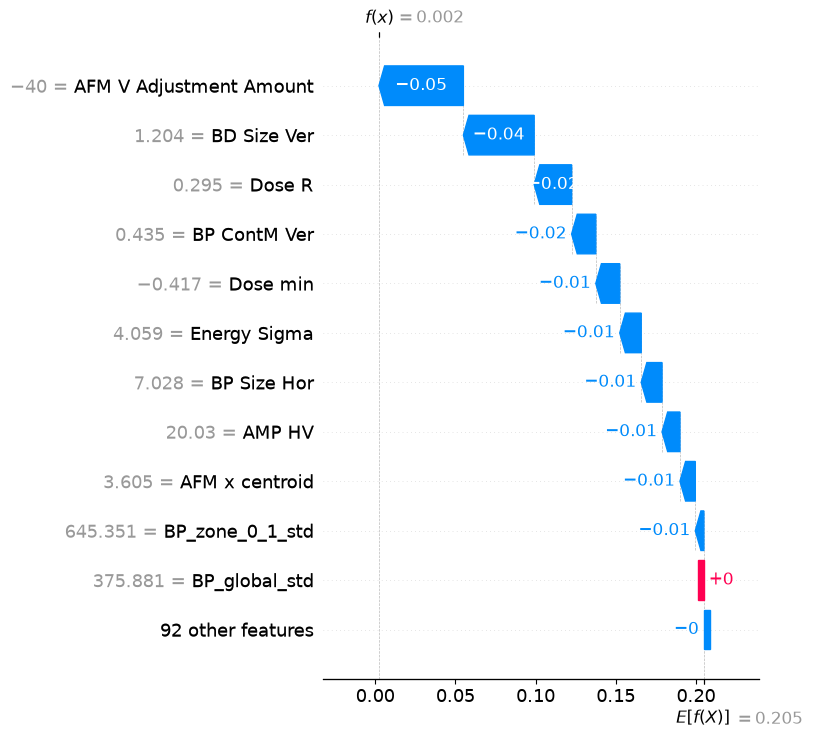

AMP - SVM (cv_winner) | sample_id=223 | false_positive | true=0 | pred=1 | P(OK)=0.602


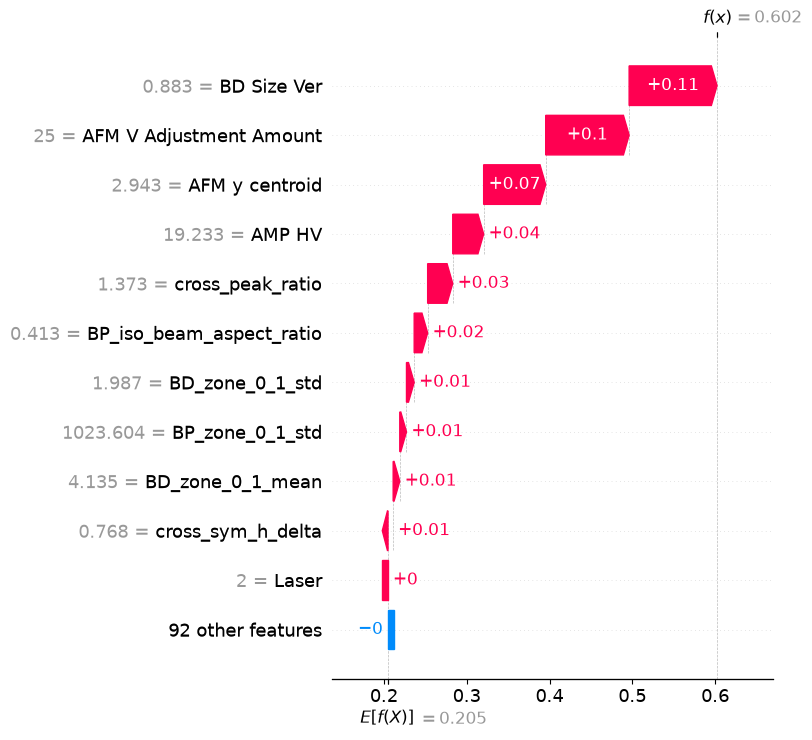

AMP - SVM (cv_winner) | sample_id=169 | false_negative | true=1 | pred=0 | P(OK)=0.070


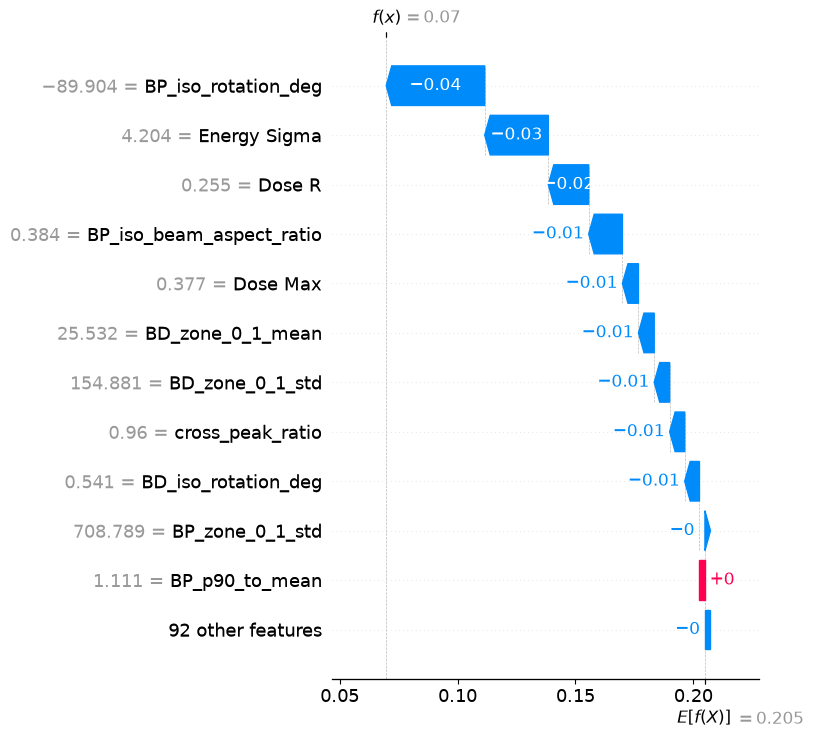


OSC CV-winner local cases


,dataset,role,model,sample_id,y_true,y_pred,proba_ok,case_type
0,OSC,cv_winner,CatBoost,182,1,1,0.996736,true_positive
1,OSC,cv_winner,CatBoost,205,0,0,0.000751,true_negative
2,OSC,cv_winner,CatBoost,301,0,1,0.987082,false_positive
3,OSC,cv_winner,CatBoost,82,1,0,0.116020,false_negative


OSC - CatBoost (cv_winner) | sample_id=182 | true_positive | true=1 | pred=1 | P(OK)=0.997


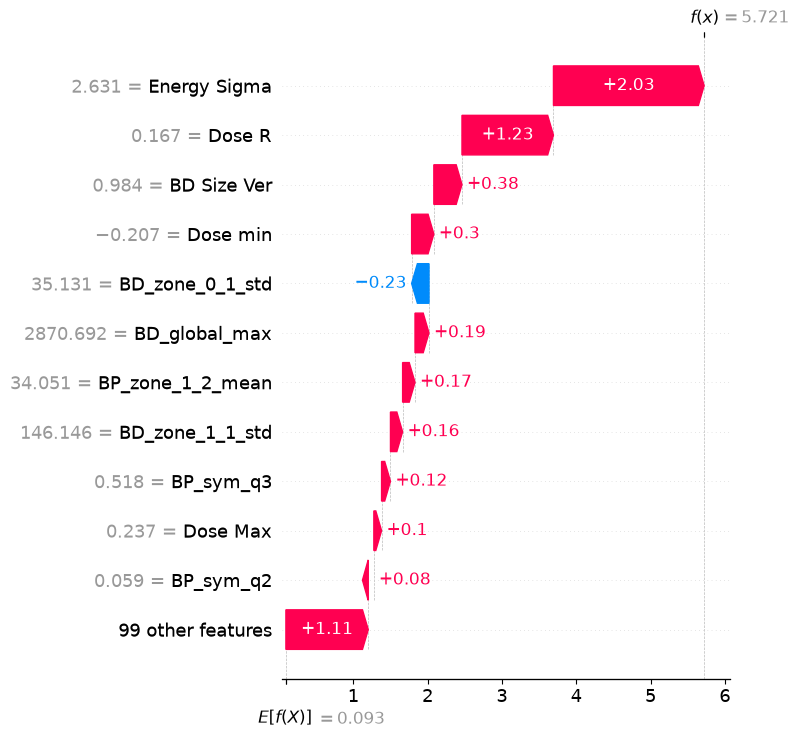

OSC - CatBoost (cv_winner) | sample_id=205 | true_negative | true=0 | pred=0 | P(OK)=0.001


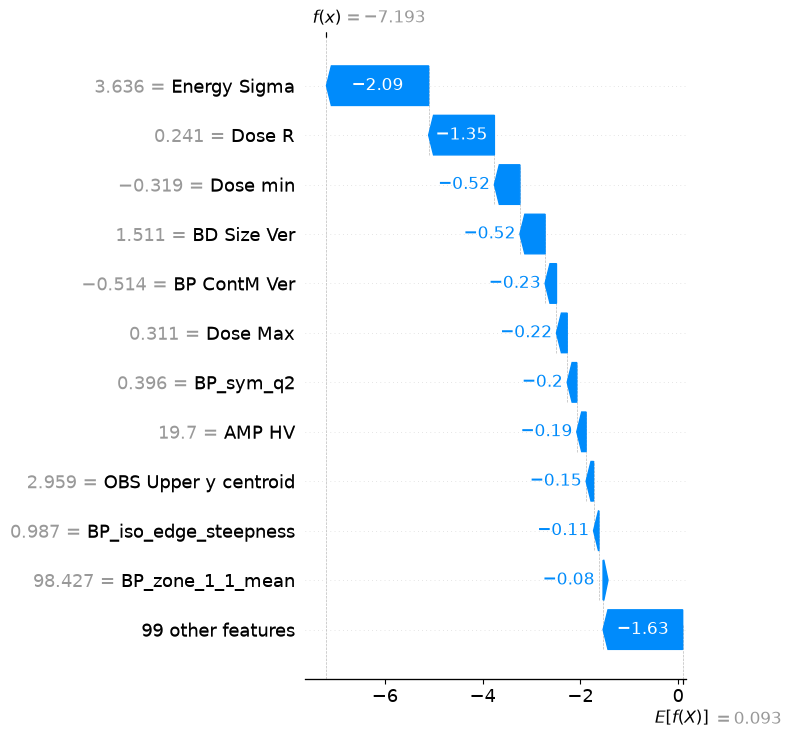

OSC - CatBoost (cv_winner) | sample_id=301 | false_positive | true=0 | pred=1 | P(OK)=0.987


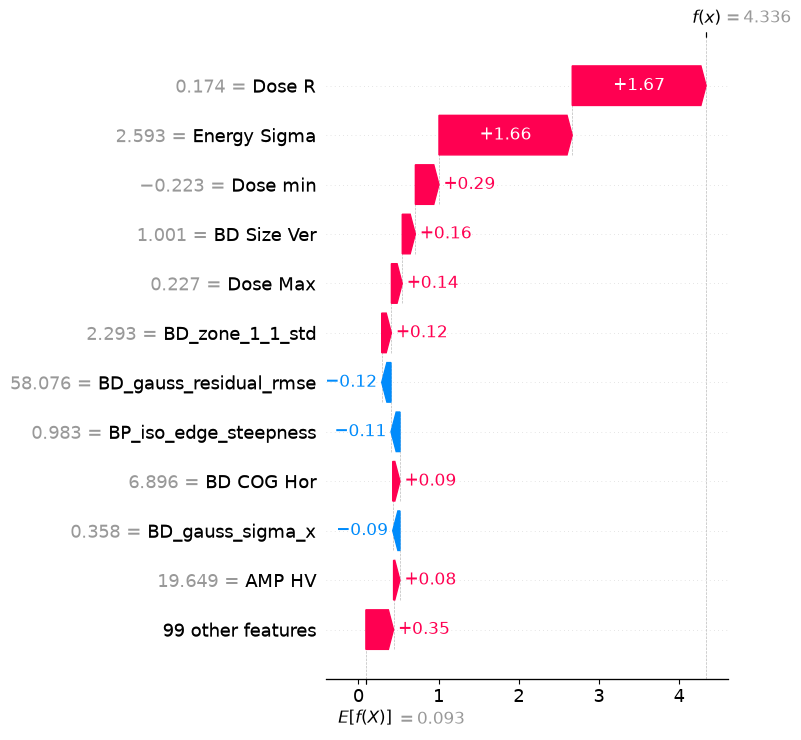

OSC - CatBoost (cv_winner) | sample_id=82 | false_negative | true=1 | pred=0 | P(OK)=0.116


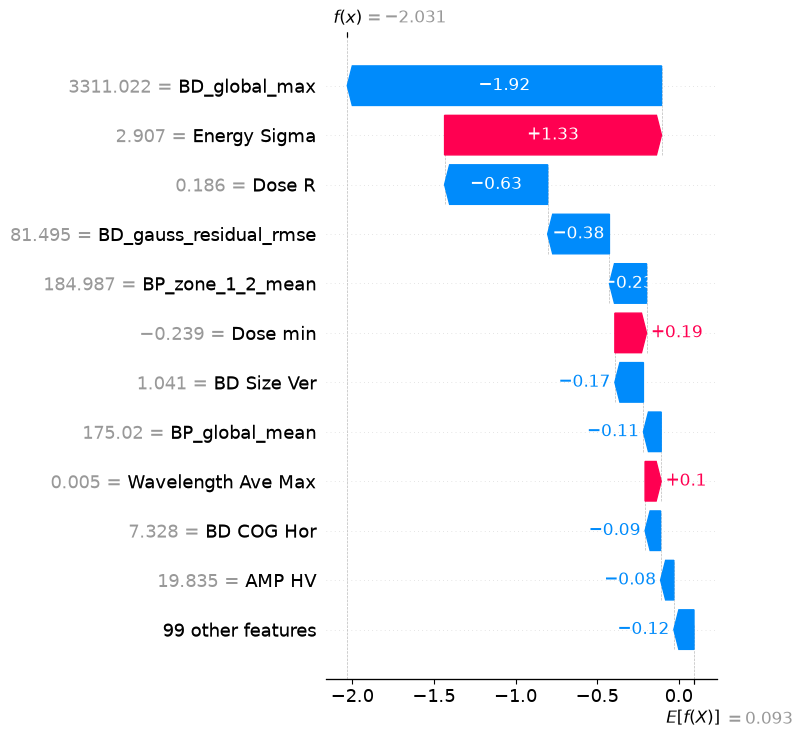

In [145]:
# Optional: local explanations for CV-winner models where they differ from the primary model.
for dataset_name, roles in representative_cases.items():
    if "cv_winner" not in roles:
        continue

    print(f"\n{dataset_name} CV-winner local cases")
    display(representative_cases[dataset_name]["cv_winner"])

    for _, case in representative_cases[dataset_name]["cv_winner"].iterrows():
        plot_shap_waterfall_for_sample(dataset_name, "cv_winner", case["sample_id"], max_display=12)


## Step 8: Feature Stability Across Methods

A feature is more trustworthy when it ranks highly across multiple explanation methods. This section compares native importance, permutation importance, and SHAP importance for the selected models, then summarizes overlap and rank correlation.

In [146]:
def ranked_native_importance(dataset_name, role="primary"):
    model_name = selected_model_registry[dataset_name]["primary_name"] if role == "primary" else selected_model_registry[dataset_name]["cv_winner_name"]
    importance_df = native_importance_tables[dataset_name][model_name].copy()
    if importance_df.empty:
        return pd.DataFrame(columns=["feature", "native_importance", "native_rank"])

    importance_df = importance_df.sort_values("importance", ascending=False).reset_index(drop=True)
    importance_df["native_rank"] = np.arange(1, len(importance_df) + 1)
    return importance_df.rename(columns={"importance": "native_importance"})[["feature", "native_importance", "native_rank"]]


def ranked_permutation_importance(dataset_name, role="primary"):
    importance_df = permutation_importance_tables[dataset_name][role].copy()
    importance_df = importance_df.sort_values("importance_mean", ascending=False).reset_index(drop=True)
    importance_df["permutation_rank"] = np.arange(1, len(importance_df) + 1)
    return importance_df.rename(columns={"importance_mean": "permutation_importance"})[["feature", "permutation_importance", "importance_std", "permutation_rank"]]


def ranked_shap_importance(dataset_name, role="primary"):
    result = shap_results[dataset_name][role]
    values = np.asarray(result["shap_values"])
    importance_df = pd.DataFrame(
        {
            "feature": result["X_explain"].columns,
            "shap_importance": np.abs(values).mean(axis=0),
        }
    ).sort_values("shap_importance", ascending=False).reset_index(drop=True)
    importance_df["shap_rank"] = np.arange(1, len(importance_df) + 1)
    return importance_df


In [147]:
def stability_table(dataset_name, role="primary"):
    feature_names = contexts[dataset_name]["feature_names"]
    base = pd.DataFrame({"feature": feature_names})

    merged = (
        base
        .merge(ranked_native_importance(dataset_name, role=role), on="feature", how="left")
        .merge(ranked_permutation_importance(dataset_name, role=role), on="feature", how="left")
        .merge(ranked_shap_importance(dataset_name, role=role), on="feature", how="left")
    )

    rank_cols = ["native_rank", "permutation_rank", "shap_rank"]
    max_rank = len(feature_names) + 1
    for col in rank_cols:
        merged[col] = pd.to_numeric(merged[col], errors="coerce").fillna(max_rank).astype(float)

    merged["methods_available"] = (
        merged[["native_importance", "permutation_importance", "shap_importance"]]
        .notna()
        .sum(axis=1)
    )
    merged["top10_method_count"] = (merged[rank_cols] <= 10).sum(axis=1)
    merged["top20_method_count"] = (merged[rank_cols] <= 20).sum(axis=1)
    merged["mean_rank"] = merged[rank_cols].mean(axis=1)
    merged["median_rank"] = merged[rank_cols].median(axis=1)

    return merged.sort_values(
        ["top10_method_count", "top20_method_count", "mean_rank"],
        ascending=[False, False, True],
    ).reset_index(drop=True)


stability_tables = {
    dataset_name: {role: stability_table(dataset_name, role=role) for role in shap_results[dataset_name]}
    for dataset_name in shap_results
}

stability_tables["AMP"]["primary"].head(25)


,feature,native_importance,native_rank,permutation_importance,importance_std,permutation_rank,shap_importance,shap_rank,methods_available,top10_method_count,top20_method_count,mean_rank,median_rank
0,BD Size Ver,14.003454,1.0,0.295645,0.073002,1.0,0.988540,1.0,3,3,3,1.000000,1.0
1,Energy Sigma,3.223104,4.0,0.086735,0.046734,2.0,0.280664,4.0,3,3,3,3.333333,4.0
2,Dose Max,1.429970,13.0,0.006882,0.017545,8.0,0.107307,9.0,3,2,3,10.000000,9.0
3,BD_global_std,2.246863,8.0,0.000000,0.000000,51.0,0.150267,7.0,3,2,2,22.000000,8.0
4,AFM x centroid,4.779835,2.0,-0.042752,0.041357,103.0,0.422650,2.0,3,2,2,35.666667,2.0
5,AFM V Adjustment Amount,4.699052,3.0,-0.033100,0.011711,102.0,0.311132,3.0,3,2,2,36.000000,3.0
6,BD COG Hor,2.319591,7.0,-0.006555,0.008332,98.0,0.215545,5.0,3,2,2,36.666667,7.0
7,Dose R,2.453232,5.0,-0.006553,0.015397,97.0,0.140762,8.0,3,2,2,36.666667,8.0
8,cross_edge_total_delta,2.436731,6.0,-0.017814,0.050358,101.0,0.173373,6.0,3,2,2,37.666667,6.0
9,AMP HV,1.810533,10.0,-0.004014,0.006657,94.0,0.104461,10.0,3,2,2,38.000000,10.0


In [148]:
stability_tables["OSC"]["primary"].head(25)


,feature,native_importance,native_rank,permutation_importance,importance_std,permutation_rank,shap_importance,shap_rank,methods_available,top10_method_count,top20_method_count,mean_rank,median_rank
0,Energy Sigma,0.030883,9.0,0.324996,0.102641,1.0,1.532435,1.0,3,3,3,3.666667,1.0
1,Dose R,0.031139,8.0,0.232174,0.101757,3.0,0.868361,2.0,3,3,3,4.333333,3.0
2,Dose Max,0.037088,5.0,0.092232,0.044742,4.0,0.189668,9.0,3,3,3,6.000000,5.0
3,AMP HV,0.015868,16.0,0.084808,0.055690,6.0,0.570261,4.0,3,2,3,8.666667,6.0
4,Dose min,0.018776,14.0,0.065215,0.053537,8.0,0.195136,8.0,3,2,3,10.000000,8.0
5,BD_sym_horizontal,0.012955,22.0,0.089577,0.054650,5.0,0.160099,10.0,3,2,2,12.333333,10.0
6,BD Size Ver,0.009027,32.0,0.260772,0.072845,2.0,0.602413,3.0,3,2,2,12.333333,3.0
7,BD_zone_1_1_std,0.011414,25.0,0.082713,0.058049,7.0,0.215008,7.0,3,2,2,13.000000,7.0
8,BD_marginal_skew_x,0.112399,1.0,0.054222,0.040161,10.0,0.052791,30.0,3,2,2,13.666667,10.0
9,BP_iso_rotation_deg,0.034115,6.0,0.034261,0.050920,17.0,0.055044,28.0,3,1,2,17.000000,17.0


In [149]:
def top_feature_overlap_summary(dataset_name, role="primary", top_n=20):
    table = stability_tables[dataset_name][role].copy()
    native_top = set(table.loc[table["native_rank"] <= top_n, "feature"])
    perm_top = set(table.loc[table["permutation_rank"] <= top_n, "feature"])
    shap_top = set(table.loc[table["shap_rank"] <= top_n, "feature"])

    available_sets = {
        "native": native_top,
        "permutation": perm_top,
        "shap": shap_top,
    }
    available_sets = {name: values for name, values in available_sets.items() if values}

    common_all = set.intersection(*available_sets.values()) if available_sets else set()
    union_all = set.union(*available_sets.values()) if available_sets else set()

    rows = [
        {"comparison": "common_to_all_available_methods", "n_features": len(common_all), "features": sorted(common_all)},
        {"comparison": "union_of_all_available_methods", "n_features": len(union_all), "features": sorted(union_all)},
        {"comparison": "native_and_permutation", "n_features": len(native_top & perm_top), "features": sorted(native_top & perm_top)},
        {"comparison": "native_and_shap", "n_features": len(native_top & shap_top), "features": sorted(native_top & shap_top)},
        {"comparison": "permutation_and_shap", "n_features": len(perm_top & shap_top), "features": sorted(perm_top & shap_top)},
    ]

    return pd.DataFrame(rows)


top_feature_overlap_summary("AMP", role="primary", top_n=20)


,comparison,n_features,features
0,common_to_all_available_methods,6,"[AFM H Adjustment Amount, BD Size Ver, BP Size..."
1,union_of_all_available_methods,36,"[AFM H Adjustment Amount, AFM V Adjustment Amo..."
2,native_and_permutation,8,"[AFM H Adjustment Amount, BD Size Ver, BP Size..."
3,native_and_shap,15,"[AFM H Adjustment Amount, AFM V Adjustment Amo..."
4,permutation_and_shap,7,"[AFM H Adjustment Amount, BD Size Ver, BP Cont..."


In [150]:
top_feature_overlap_summary("OSC", role="primary", top_n=20)


,comparison,n_features,features
0,common_to_all_available_methods,6,"[AMP HV, Dose Max, Dose R, Dose min, Energy Si..."
1,union_of_all_available_methods,40,"[AMP HV, BD COG Hor, BD Size Ver, BD_edge_righ..."
2,native_and_permutation,9,"[AMP HV, BD_marginal_skew_x, BP_iso_rotation_d..."
3,native_and_shap,7,"[AMP HV, BD_global_max, Dose Max, Dose R, Dose..."
4,permutation_and_shap,10,"[AMP HV, BD Size Ver, BD_sym_horizontal, BD_zo..."


In [151]:
def rank_correlation_summary(dataset_name, role="primary"):
    table = stability_tables[dataset_name][role].copy()
    rank_cols = ["native_rank", "permutation_rank", "shap_rank"]

    available_rank_cols = []
    for col in rank_cols:
        importance_col = col.replace("_rank", "_importance")
        if importance_col in table.columns and table[importance_col].notna().any():
            available_rank_cols.append(col)

    if len(available_rank_cols) < 2:
        return pd.DataFrame()

    corr = table[available_rank_cols].corr(method="spearman")
    return corr


rank_correlation_summary("AMP", role="primary")


,native_rank,permutation_rank,shap_rank
native_rank,1.000000,-0.043766,0.875258
permutation_rank,-0.043766,1.000000,-0.060713
shap_rank,0.875258,-0.060713,1.000000


In [152]:
rank_correlation_summary("OSC", role="primary")


,native_rank,permutation_rank,shap_rank
native_rank,1.000000,0.434953,0.716430
permutation_rank,0.434953,1.000000,0.456051
shap_rank,0.716430,0.456051,1.000000


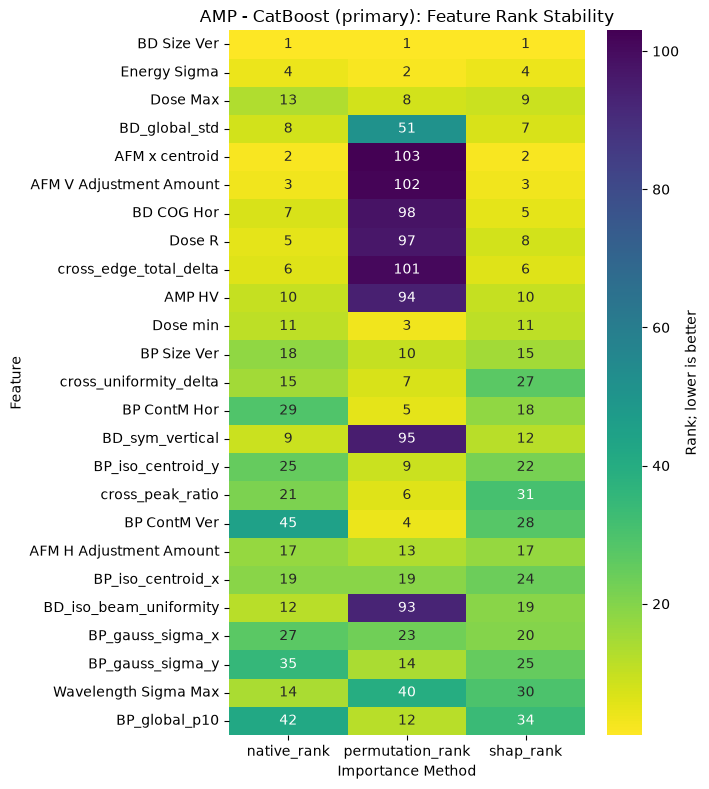

In [153]:
def plot_stability_heatmap(dataset_name, role="primary", top_n=25):
    table = stability_tables[dataset_name][role].head(top_n).copy()
    rank_cols = ["native_rank", "permutation_rank", "shap_rank"]
    plot_df = table.set_index("feature")[rank_cols].apply(pd.to_numeric, errors="coerce")

    fig, ax = plt.subplots(figsize=(7, max(6, top_n * 0.32)))
    sns.heatmap(
        plot_df,
        annot=True,
        fmt=".0f",
        cmap="viridis_r",
        cbar_kws={"label": "Rank; lower is better"},
        ax=ax,
    )
    model_name = selected_model_registry[dataset_name]["primary_name"] if role == "primary" else selected_model_registry[dataset_name]["cv_winner_name"]
    ax.set_title(f"{dataset_name} - {model_name} ({role}): Feature Rank Stability")
    ax.set_xlabel("Importance Method")
    ax.set_ylabel("Feature")
    plt.tight_layout()
    plt.show()


plot_stability_heatmap("AMP", role="primary", top_n=25)


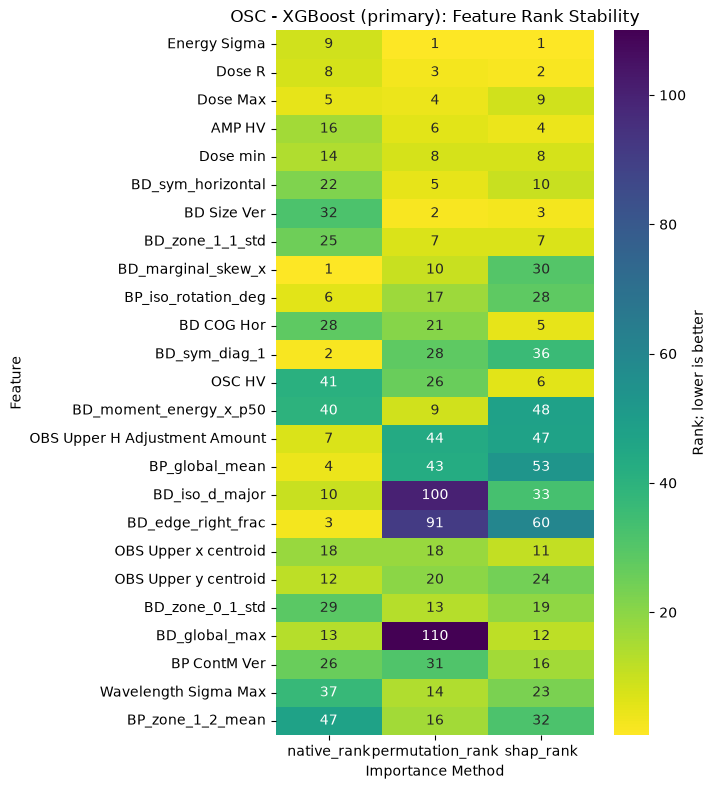

In [154]:
plot_stability_heatmap("OSC", role="primary", top_n=25)


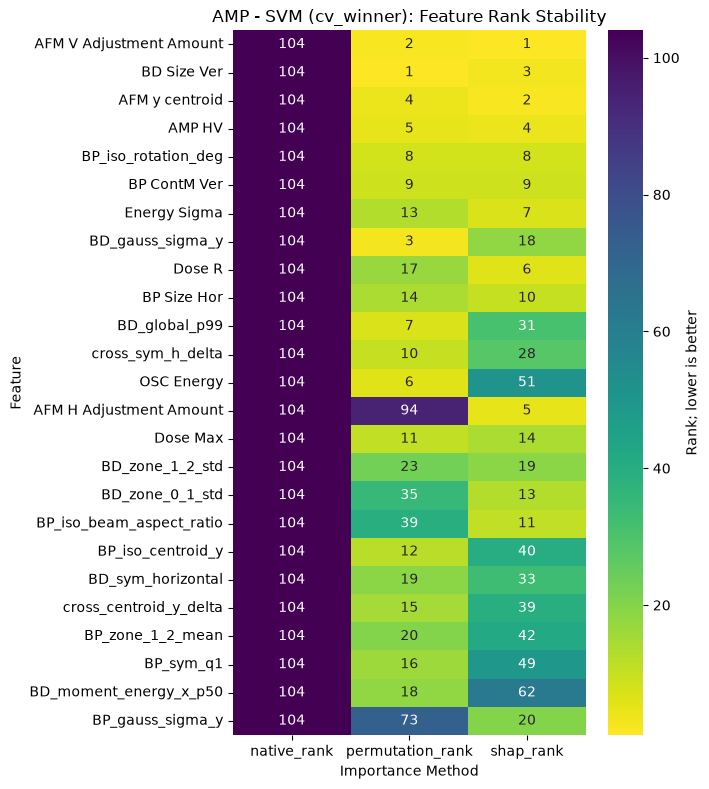

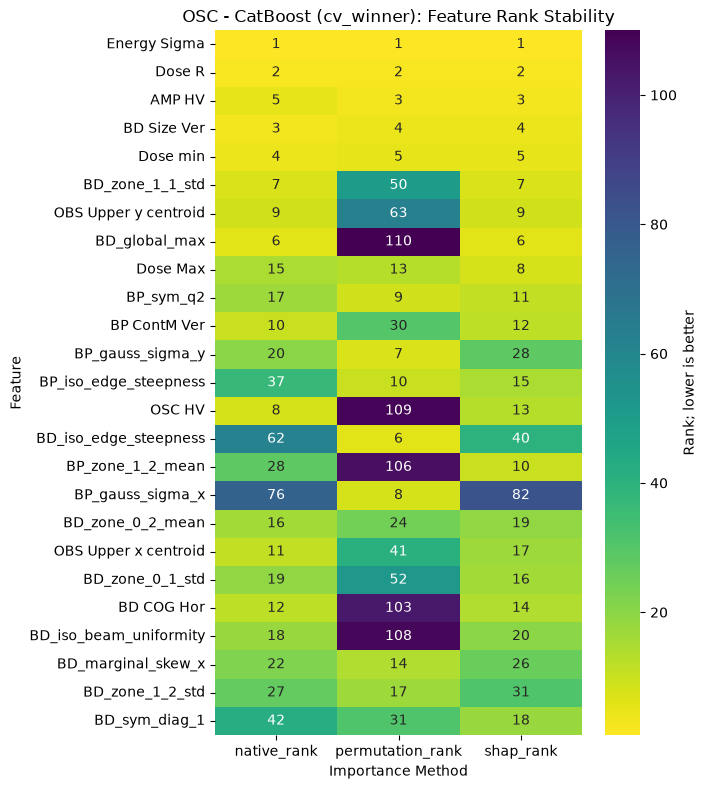

In [155]:
# CV-winner stability heatmaps, where the CV winner differs from the primary model.
for dataset_name, role_tables in stability_tables.items():
    if "cv_winner" in role_tables:
        plot_stability_heatmap(dataset_name, role="cv_winner", top_n=25)


In [156]:
# CV-winner stability sensitivity, where available.
for dataset_name, role_tables in stability_tables.items():
    if "cv_winner" not in role_tables:
        continue

    print(f"\n{dataset_name} CV-winner stability table")
    display(role_tables["cv_winner"].head(25))
    print("Overlap summary")
    display(top_feature_overlap_summary(dataset_name, role="cv_winner", top_n=20))
    print("Rank correlations")
    display(rank_correlation_summary(dataset_name, role="cv_winner"))



AMP CV-winner stability table


,feature,native_importance,native_rank,permutation_importance,importance_std,permutation_rank,shap_importance,shap_rank,methods_available,top10_method_count,top20_method_count,mean_rank,median_rank
0,AFM V Adjustment Amount,NaN,104.0,0.030695,0.039060,2.0,0.032007,1.0,2,2,2,35.666667,2.0
1,BD Size Ver,NaN,104.0,0.072827,0.030867,1.0,0.025857,3.0,2,2,2,36.000000,3.0
2,AFM y centroid,NaN,104.0,0.023013,0.027615,4.0,0.028711,2.0,2,2,2,36.666667,4.0
3,AMP HV,NaN,104.0,0.015495,0.032043,5.0,0.016293,4.0,2,2,2,37.666667,5.0
4,BP_iso_rotation_deg,NaN,104.0,0.011711,0.022995,8.0,0.007256,8.0,2,2,2,40.000000,8.0
5,BP ContM Ver,NaN,104.0,0.010462,0.016762,9.0,0.006884,9.0,2,2,2,40.666667,9.0
6,Energy Sigma,NaN,104.0,0.009348,0.015373,13.0,0.009977,7.0,2,1,2,41.333333,13.0
7,BD_gauss_sigma_y,NaN,104.0,0.028335,0.014020,3.0,0.003977,18.0,2,1,2,41.666667,18.0
8,Dose R,NaN,104.0,0.008485,0.017905,17.0,0.010179,6.0,2,1,2,42.333333,17.0
9,BP Size Hor,NaN,104.0,0.008906,0.018668,14.0,0.006486,10.0,2,1,2,42.666667,14.0


Overlap summary


,comparison,n_features,features
0,common_to_all_available_methods,11,"[AFM V Adjustment Amount, AFM y centroid, AMP ..."
1,union_of_all_available_methods,29,"[AFM H Adjustment Amount, AFM V Adjustment Amo..."
2,native_and_permutation,0,[]
3,native_and_shap,0,[]
4,permutation_and_shap,11,"[AFM V Adjustment Amount, AFM y centroid, AMP ..."


Rank correlations


...

,feature,native_importance,native_rank,permutation_importance,importance_std,permutation_rank,shap_importance,shap_rank,methods_available,top10_method_count,top20_method_count,mean_rank,median_rank
0,Energy Sigma,21.879149,1.0,0.123706,0.054140,1.0,1.906099,1.0,3,3,3,1.000000,1.0
1,Dose R,10.627719,2.0,0.110681,0.081478,2.0,0.978479,2.0,3,3,3,2.000000,2.0
2,AMP HV,4.490544,5.0,0.106546,0.060603,3.0,0.443537,3.0,3,3,3,3.666667,3.0
3,BD Size Ver,5.287887,3.0,0.083042,0.045844,4.0,0.427792,4.0,3,3,3,3.666667,4.0
4,Dose min,4.750207,4.0,0.044338,0.036158,5.0,0.355139,5.0,3,3,3,4.666667,5.0
5,BD_zone_1_1_std,2.151570,7.0,0.008472,0.040837,50.0,0.228185,7.0,3,2,2,21.333333,7.0
6,OBS Upper y centroid,1.474236,9.0,0.003374,0.023256,63.0,0.132158,9.0,3,2,2,27.000000,9.0
7,BD_global_max,2.978474,6.0,-0.077280,0.058753,110.0,0.242937,6.0,3,2,2,40.666667,6.0
8,Dose Max,1.011670,15.0,0.034677,0.012434,13.0,0.138039,8.0,3,1,3,12.000000,13.0
9,BP_sym_q2,0.932119,17.0,0.038378,0.038491,9.0,0.095852,11.0,3,1,3,12.333333,11.0


Overlap summary


,comparison,n_features,features
0,common_to_all_available_methods,7,"[AMP HV, BD Size Ver, BP_sym_q2, Dose Max, Dos..."
1,union_of_all_available_methods,34,"[AMP HV, BD COG Hor, BD Size Hor, BD Size Ver,..."
2,native_and_permutation,8,"[AMP HV, BD Size Ver, BP_gauss_sigma_y, BP_sym..."
3,native_and_shap,17,"[AMP HV, BD COG Hor, BD Size Ver, BD_global_ma..."
4,permutation_and_shap,8,"[AMP HV, BD Size Ver, BP_iso_edge_steepness, B..."


Rank correlations


,native_rank,permutation_rank,shap_rank
native_rank,1.000000,0.209918,0.905913
permutation_rank,0.209918,1.000000,0.208088
shap_rank,0.905913,0.208088,1.000000
